# Análise Exploratória do Mercado de Cinema Brasileiro

Análise exploratória dos dados de bilheteria do mercado cinematográfico nacional,
utilizando dados públicos da **ANCINE (Agência Nacional do Cinema)**.

**Período coberto:** janeiro de 2014 a junho de 2026

> ⚠️ Os dados de **2026 são parciais** — cobrem apenas de janeiro a junho.
> Todas as comparações anuais que incluam 2026 indicarão isso explicitamente.

---

## Perguntas investigadas

1. **Impacto da pandemia de COVID-19:** Como e quando o mercado foi afetado?
   Qual a magnitude da queda?
2. **Recuperação do mercado:** O público retornou aos patamares pré-pandemia?
   Em que ritmo?
3. **Filmes premiados:** Qual o impacto de *Ainda Estou Aqui* e *O Agente Secreto*
   na bilheteria do cinema nacional?
4. **Cinema nacional vs. estrangeiro:** Como evolui a participação do cinema
   brasileiro ao longo dos anos?
5. **Sazonalidade:** Existem padrões sazonais consistentes no consumo de cinema?
6. **Distribuição geográfica:** Como o público se distribui entre estados e regiões?

---

> **Sobre os dados:** Os registros da ANCINE contabilizam **público** (número de
> espectadores por sessão/dia/sala), não receita financeira. A identificação de filmes
> nacionais é feita pelo prefixo `B` no campo `CPB_ROE` (código de registro ANCINE).

---
## Seção 0 — Setup e Configurações

Nesta seção preparamos o ambiente de análise:
- Importação das bibliotecas necessárias
- Definição dos caminhos de entrada e saída
- Configurações visuais do matplotlib
- Funções auxiliares para salvar figuras e formatar eixos

In [1]:
# ── Manipulação e análise de dados ──────────────────────────
import pandas as pd
import numpy as np

# ── Visualização ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Utilitários de sistema ───────────────────────────────────
import glob
import warnings
from pathlib import Path

# Suprimir avisos não críticos para manter o output do notebook limpo
warnings.filterwarnings('ignore')

# Confirmar versões das principais bibliotecas
print(f'pandas  {pd.__version__}')
print(f'numpy   {np.__version__}')
print(f'seaborn {sns.__version__}')

pandas  2.3.3
numpy   2.0.2
seaborn 0.13.2


In [2]:
# ═══════════════════════════════════════════════════════════════
# CAMINHOS
# ═══════════════════════════════════════════════════════════════
# O notebook fica em notebooks/, então o diretório raiz está
# um nível acima. Path.resolve() garante o caminho absoluto.
ROOT_DIR = Path('..').resolve()

DATA_DIR        = ROOT_DIR / 'data'                 # CSVs brutos ANCINE (não versionados)
FIGURES_DIR     = ROOT_DIR / 'outputs' / 'figures'  # Gráficos exportados (versionados)
OUTPUT_DATA_DIR = ROOT_DIR / 'outputs' / 'processados'  # Dados processados/agregados (versionados)

# Criar os diretórios de saída caso não existam
# (útil quando o notebook é executado em um ambiente limpo)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f'Dados brutos:   {DATA_DIR}')
print(f'Figuras:        {FIGURES_DIR}')
print(f'Dados gerados:  {OUTPUT_DATA_DIR}')

# ═══════════════════════════════════════════════════════════════
# CONFIGURAÇÕES DE VISUALIZAÇÃO
# ═══════════════════════════════════════════════════════════════
# Estilo base: grade de fundo clara, sem bordas superiores/direitas
plt.style.use('seaborn-v0_8-whitegrid')

# Parâmetros globais aplicados a todos os gráficos do notebook
plt.rcParams.update({
    'figure.figsize':    (14, 6),  # tamanho padrão: largo e não muito alto
    'figure.dpi':        100,
    'font.size':         12,
    'axes.titlesize':    14,
    'axes.labelsize':    12,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   11,
    'axes.spines.top':   False,  # remover bordas superior e direita
    'axes.spines.right': False,  # deixa o gráfico mais limpo visualmente
})

# Paleta de cores padronizada para o projeto.
# Usar sempre as mesmas cores para os mesmos conceitos facilita
# a leitura e a comparação entre gráficos.
CORES = {
    'nacional':    '#1f77b4',  # azul    — cinema nacional
    'estrangeiro': '#ff7f0e',  # laranja — cinema estrangeiro
    'pandemia':    '#d62728',  # vermelho — período pandemia
    'destaque':    '#2ca02c',  # verde   — filmes premiados
    'neutro':      '#7f7f7f',  # cinza   — 2026 (ano incompleto)
    'total':       '#17becf',  # ciano   — totais gerais
}

# Nomes dos meses em português (usado em eixos e rótulos com datas)
MESES_PT = {
    1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr',
    5: 'Mai', 6: 'Jun', 7: 'Jul', 8: 'Ago',
    9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez',
}

# ═══════════════════════════════════════════════════════════════
# FUNÇÕES AUXILIARES
# ═══════════════════════════════════════════════════════════════
def salvar_figura(nome: str) -> None:
    """Salva a figura matplotlib atual em outputs/figures/."""
    caminho = FIGURES_DIR / nome
    plt.savefig(caminho, dpi=150, bbox_inches='tight')
    print(f'Figura salva: outputs/figures/{nome}')


def formatar_milhoes(x, pos=None) -> str:
    """Formata valores do eixo Y em milhões (ex: 5,2M) para legibilidade."""
    return f'{x/1_000_000:.1f}M'


print('Configurações aplicadas com sucesso.')

Dados brutos:   /Users/matheus/Documents/eda-mercado-cinema-brasil/data
Figuras:        /Users/matheus/Documents/eda-mercado-cinema-brasil/outputs/figures
Dados gerados:  /Users/matheus/Documents/eda-mercado-cinema-brasil/outputs/processados
Configurações aplicadas com sucesso.


---
## Seção 1 — Carregamento e Otimização de Memória

Os dados da ANCINE estão distribuídos em **150 arquivos CSV** mensais
(jan/2014 a jun/2026), totalizando aproximadamente **4,5 GB em disco** e
**20,9 milhões de linhas**.

### Estratégia de carregamento

Carregar tudo de uma vez exige cuidado com o uso de memória. As otimizações adotadas são:

| Técnica | Por quê | Ganho estimado |
|---------|---------|----------------|
| `dtype='category'` para colunas com poucos valores únicos | Armazena como inteiro com tabela de mapeamento | Até 90% vs. `object` |
| `dtype='int32'` para `PUBLICO` | Valores até ~2.100 — não precisa de int64 | 50% vs. `int64` |
| `dtype='Int32'` (nullable) para IDs com nulos | Evita conversão automática para `float64` | 50% vs. `float64` |
| Descartar 3 colunas não utilizadas na leitura | Reduz a quantidade de dados carregados | ~15% |
| Converter `DATA_EXIBICAO` após o concat | Parsear datas uma vez só, no DataFrame completo | Mais rápido |

**Resultado esperado:** ~1,5–2,0 GB em RAM (vs. ~4,5 GB sem otimização de tipos).

In [3]:
# ═══════════════════════════════════════════════════════════════
# TIPOS DE DADOS OTIMIZADOS
# ═══════════════════════════════════════════════════════════════
# Definir os dtypes NA LEITURA (e não depois) é essencial:
# se carregarmos como object/int64 e convertermos depois, o pandas
# mantém as duas versões na memória simultaneamente durante a conversão.

DTYPES = {
    # ── Texto com alta repetição → 'category' ─────────────────
    # 'category' armazena os dados como inteiros internamente,
    # mantendo apenas uma tabela de mapeamento para os valores únicos.
    # Ideal quando os mesmos valores se repetem milhões de vezes.

    'TITULO_ORIGINAL':            'category',  # mesmo filme em N salas × N dias
    'TITULO_BRASIL':              'category',  # mesma lógica
    'CPB_ROE':                    'category',  # código ANCINE — B=nacional, E=estrangeiro
    'PAIS_OBRA':                  'category',  # ~50 países únicos em todo o dataset
    'NOME_SALA':                  'category',  # cada sala repete todos os dias que exibe
    'MUNICIPIO_SALA_COMPLEXO':    'category',  # ~500 municípios únicos
    'UF_SALA_COMPLEXO':           'category',  # exatamente 27 valores (siglas dos estados)
    'RAZAO_SOCIAL_DISTRIBUIDORA': 'category',  # poucas dezenas de distribuidoras

    # ── Público: int32 é suficiente ───────────────────────────
    # Valores típicos: 1–1.600 espectadores por sala por dia.
    # int32 suporta até ~2,1 bilhões — mais que suficiente.
    'PUBLICO': 'int32',

    # ── IDs numéricos com nulos ───────────────────────────────
    # Int32 (maiúsculo) é a versão nullable do pandas (>=1.0).
    # Sem ele, o pandas converteria automaticamente para float64
    # na presença de qualquer nulo, dobrando o consumo de memória.
    'REGISTRO_SALA':           'Int32',  # 0,16% de nulos em anos antigos
    'REGISTRO_COMPLEXO':       'Int32',
    'REGISTRO_EXIBIDOR':       'Int32',
    'REGISTRO_GRUPO_EXIBIDOR': 'Int32',  # 8,6% de nulos
}

# Colunas sem utilidade para a análise — descartadas durante a leitura
COLUNAS_DESCARTAR = [
    'NR_PROTOCOLO_ENVIO',         # número interno do protocolo ANCINE
    'DATA_HORA_ENVIO_PROTOCOLO',  # timestamp do envio pelo exibidor (≠ data de exibição)
    'CNPJ_DISTRIBUIDORA',         # redundante — já temos RAZAO_SOCIAL_DISTRIBUIDORA
]

print(f'Dtypes otimizados para {len(DTYPES)} colunas')
print(f'Colunas descartadas na leitura: {COLUNAS_DESCARTAR}')

Dtypes otimizados para 13 colunas
Colunas descartadas na leitura: ['NR_PROTOCOLO_ENVIO', 'DATA_HORA_ENVIO_PROTOCOLO', 'CNPJ_DISTRIBUIDORA']


In [4]:
# ═══════════════════════════════════════════════════════════════
# CARREGAMENTO DOS ARQUIVOS CSV
# ═══════════════════════════════════════════════════════════════
# Localizar todos os arquivos no diretório de dados.
# sorted() garante leitura em ordem cronológica (jan/2014 → jun/2026).
arquivos = sorted(glob.glob(str(DATA_DIR / '*.csv')))

print(f'Arquivos encontrados: {len(arquivos)}')
print(f'  Primeiro: {Path(arquivos[0]).name}')
print(f'  Último:   {Path(arquivos[-1]).name}')
print()

# ── Carregamento em lista + concat ao final ───────────────────
# Por que não concat em loop?
# pd.concat dentro de um loop é O(n²) — cada iteração cria uma
# cópia completa do DataFrame acumulado. Com 150 arquivos, isso
# seria extremamente lento e desperdiçaria muita memória.
# A abordagem correta: guardar tudo em lista e fazer um único concat.
print('Carregando arquivos... (pode levar alguns minutos)')

dfs = []
for i, caminho in enumerate(arquivos, 1):
    df_mes = pd.read_csv(
        caminho,
        sep=';',                                        # separador padrão ANCINE
        encoding='utf-8',                              # verificado em todos os 150 arquivos
        dtype=DTYPES,                                  # tipos otimizados definidos acima
        usecols=lambda c: c not in COLUNAS_DESCARTAR, # descartar na leitura, não depois
    )
    dfs.append(df_mes)

    # Exibir progresso a cada 10 arquivos e ao final
    if i % 10 == 0 or i == len(arquivos):
        print(f'  {i:>3}/{len(arquivos)} arquivos carregados...')

# Concatenar tudo em um único DataFrame
# ignore_index=True: reconstrói o índice de 0 a N (evita índices duplicados)
df = pd.concat(dfs, ignore_index=True)

# Liberar a lista intermediária para recuperar a memória alocada
del dfs

# ── Reconversão de colunas category ─────────────────────────
# pd.concat converte colunas 'category' para 'object' quando as
# categorias diferem entre os DataFrames concatenados (o que
# acontece aqui: cada mês tem filmes diferentes). Reconvertemos
# explicitamente para recuperar a otimização de memória.
colunas_category = [col for col, dtype in DTYPES.items() if dtype == 'category']
for col in colunas_category:
    if col in df.columns and df[col].dtype == object:
        df[col] = df[col].astype('category')

print(f'\nCarregamento concluído!')
print(f'  Linhas totais: {len(df):>12,}')
print(f'  Colunas:       {df.shape[1]:>12}')

Arquivos encontrados: 150
  Primeiro: bilheteria-diaria-obras-por-distribuidoras-2014-01.csv
  Último:   bilheteria-diaria-obras-por-distribuidoras-2026-06.csv

Carregando arquivos... (pode levar alguns minutos)


   10/150 arquivos carregados...


   20/150 arquivos carregados...


   30/150 arquivos carregados...


   40/150 arquivos carregados...


...

  120/150 arquivos carregados...


  130/150 arquivos carregados...


  140/150 arquivos carregados...


  150/150 arquivos carregados...



Carregamento concluído!
  Linhas totais:   20,916,062
  Colunas:                 14


In [5]:
# ═══════════════════════════════════════════════════════════════
# CONVERSÃO DA COLUNA DE DATA
# ═══════════════════════════════════════════════════════════════
# DATA_EXIBICAO foi lida como string no formato DD/MM/AAAA.
# Convertemos para datetime APÓS o concat porque é mais eficiente:
# parsear datas uma vez no DataFrame completo é mais rápido do que
# parsear em cada um dos 150 arquivos individualmente.
#
# O formato explícito '%d/%m/%Y' é mais rápido do que inferência automática.
df['DATA_EXIBICAO'] = pd.to_datetime(df['DATA_EXIBICAO'], format='%d/%m/%Y')

# Confirmar o período coberto
data_inicio = df['DATA_EXIBICAO'].min().date()
data_fim    = df['DATA_EXIBICAO'].max().date()
print(f'Período coberto: {data_inicio}  →  {data_fim}')
print()

# ═══════════════════════════════════════════════════════════════
# DIAGNÓSTICO DE MEMÓRIA
# ═══════════════════════════════════════════════════════════════
# memory_usage(deep=True) considera o conteúdo real das colunas
# de tipo object/category (não apenas os ponteiros), dando um
# número preciso do consumo real em memória.
mem_atual_mb = df.memory_usage(deep=True).sum() / 1_048_576

# Tamanho total em disco como referência de comparação
tamanho_disco_mb = sum(
    Path(f).stat().st_size for f in arquivos
) / 1_048_576

print('Uso de memória do DataFrame:')
print(f'  Em memória (otimizado): {mem_atual_mb:>8.0f} MB')
print(f'  Em disco (referência):  {tamanho_disco_mb:>8.0f} MB')
print()

# Detalhe por coluna — identifica as que mais consomem memória
mem_por_coluna = (
    df.memory_usage(deep=True)
      .drop('Index')              # excluir o índice do ranking
      .sort_values(ascending=False)
      .head(8)                    # top 8 colunas mais pesadas
      .apply(lambda x: f'{x/1_048_576:.1f} MB')
)
print('Top 8 colunas por consumo de memória:')
print(mem_por_coluna.to_string())

Período coberto: 2014-01-01  →  2026-06-13

Uso de memória do DataFrame:
  Em memória (otimizado):      921 MB
  Em disco (referência):      4637 MB

Top 8 colunas por consumo de memória:
DATA_EXIBICAO              159.6 MB
REGISTRO_SALA               99.7 MB
REGISTRO_GRUPO_EXIBIDOR     99.7 MB
REGISTRO_EXIBIDOR           99.7 MB
REGISTRO_COMPLEXO           99.7 MB
PUBLICO                     79.8 MB
NOME_SALA                   41.6 MB
TITULO_ORIGINAL             40.5 MB


---
## Seção 2 — Limpeza e Padronização dos Dados

Antes de qualquer análise, aplicamos três grupos de transformações:

1. **Remoção de registros inválidos** — público zero presente apenas em 2014
2. **Preenchimento de valores ausentes** — `TITULO_BRASIL` vazio em 4%–31% das linhas
3. **Correção de acentuação em `PAIS_OBRA`** — único problema de padronização
   encontrado nos dados (ex: `JAPAO` vs `JAPÃO`)
4. **Criação de colunas derivadas** — facilitam os agrupamentos temporais e de origem

> **Sobre a qualidade geral dos dados:** exceto pela acentuação inconsistente de `PAIS_OBRA`,
> os dados ANCINE são bem padronizados — mesmas siglas de UF, municípios com acentuação
> consistente, e títulos de filmes sem variações de grafia.

In [6]:
# ═══════════════════════════════════════════════════════════════
# 2.1 — REMOÇÃO DE REGISTROS COM PÚBLICO ZERO
# ═══════════════════════════════════════════════════════════════
# Em 2014, cerca de 7.400 linhas (~5,7% daquele ano) têm PUBLICO == 0.
# A partir de 2015, esse problema desaparece completamente.
# Esses registros parecem ser testes ou exibições sem público registrado
# e seriam ruído nas análises de público.

registros_antes = len(df)
zeros_por_ano = df[df['PUBLICO'] == 0].groupby(df['DATA_EXIBICAO'].dt.year).size()

if len(zeros_por_ano) > 0:
    print('Registros com público zero por ano:')
    print(zeros_por_ano.to_string())
    print()

# Remover todas as linhas com público zero
df = df[df['PUBLICO'] > 0].copy()

registros_removidos = registros_antes - len(df)
print(f'Registros removidos (público zero): {registros_removidos:,}')
print(f'Registros restantes:                {len(df):,}')

Registros com público zero por ano:
DATA_EXIBICAO
2014    134156
2015     38391



Registros removidos (público zero): 172,547
Registros restantes:                20,743,515


In [7]:
# ═══════════════════════════════════════════════════════════════
# 2.2 — PREENCHIMENTO DE TITULO_BRASIL
# ═══════════════════════════════════════════════════════════════
# TITULO_BRASIL está vazio em 4% a 31% das linhas dependendo do ano.
# O percentual varia porque:
#   - Filmes nacionais frequentemente não têm título traduzido
#   - Filmes mais antigos têm mais campos faltantes nos registros ANCINE
# Solução: usar TITULO_ORIGINAL quando TITULO_BRASIL está ausente.

# Percentual de nulos por ano antes da correção
nulos_antes = df.groupby(df["DATA_EXIBICAO"].dt.year)["TITULO_BRASIL"].apply(
    lambda x: x.isna().mean() * 100
).round(1)
print("% de TITULO_BRASIL vazio por ano (antes):")
print(nulos_antes.to_string())
print()

# Após pd.concat de muitos arquivos, colunas category podem ser convertidas
# para object pelo pandas quando as categorias diferem entre arquivos.
# A abordagem mais robusta: converter para object, fazer o fillna, e
# reconverter para category — evita problemas de sincronização de categorias.
df["TITULO_BRASIL"] = (
    df["TITULO_BRASIL"].astype(object)
    .fillna(df["TITULO_ORIGINAL"].astype(object))
    .astype("category")
)

nulos_depois = df["TITULO_BRASIL"].isna().sum()
print(f"Nulos em TITULO_BRASIL após preenchimento: {nulos_depois}")

% de TITULO_BRASIL vazio por ano (antes):
DATA_EXIBICAO
2014    15.8
2015    15.5
2016    15.9
2017    14.8
2018    14.7
2019    15.6
2020    11.4
2021     4.1
2022     9.9
2023     7.7
2024    15.5
2025    14.6
2026    11.0



Nulos em TITULO_BRASIL após preenchimento: 0


In [8]:
# ═══════════════════════════════════════════════════════════════
# 2.3 — CORREÇÃO DE ACENTUAÇÃO EM PAIS_OBRA
# ═══════════════════════════════════════════════════════════════
# Problema: alguns países perdem acentos em certos arquivos mensais.
# Exemplos: 'JAPAO' → 'JAPÃO', 'FRANCA' → 'FRANÇA', 'ITALIA' → 'ITÁLIA'

CORRECOES_PAIS = {
    'JAPAO':  'JAPÃO',
    'FRANCA': 'FRANÇA',
    'ITALIA': 'ITÁLIA',
    'LIBANO': 'LÍBANO',
}

# .unique() funciona com dtype object e category — mais robusto que .cat.categories
paises_unicos = df['PAIS_OBRA'].unique().tolist()
correcoes_aplicaveis = {k: v for k, v in CORRECOES_PAIS.items() if k in paises_unicos}

if correcoes_aplicaveis:
    print('Correções a aplicar:')
    for errado, correto in correcoes_aplicaveis.items():
        qtd = (df['PAIS_OBRA'] == errado).sum()
        print(f'  {errado!r:12s} → {correto!r:12s}  ({qtd:,} registros)')

    # .replace() funciona com object e category — sem necessidade de
    # sincronizar categorias manualmente
    df['PAIS_OBRA'] = df['PAIS_OBRA'].replace(correcoes_aplicaveis)
    print('\nCorreções aplicadas.')
else:
    print('Nenhuma forma incorreta encontrada — dados já estão corretos.')

print(f'\nTotal de países únicos após correção: {df["PAIS_OBRA"].nunique()}')

Correções a aplicar:
  'JAPAO'      → 'JAPÃO'       (183,903 registros)
  'FRANCA'     → 'FRANÇA'      (347,564 registros)
  'ITALIA'     → 'ITÁLIA'      (26,180 registros)
  'LIBANO'     → 'LÍBANO'      (2,111 registros)

Correções aplicadas.

Total de países únicos após correção: 81


In [9]:
# ═══════════════════════════════════════════════════════════════
# 2.4 — COLUNAS DERIVADAS
# ═══════════════════════════════════════════════════════════════
# Criamos colunas calculadas que facilitam os agrupamentos
# sem precisar recalcular em cada análise.

# ORIGEM: identifica se o filme é nacional ou estrangeiro.
# O campo CPB_ROE começa com 'B' para filmes brasileiros
# e com 'E' para estrangeiros (padrão de registro ANCINE).
df['ORIGEM'] = df['CPB_ROE'].str[0].map(
    {'B': 'Nacional', 'E': 'Estrangeiro'}
).astype('category')

# ANO e MES: extraídos de DATA_EXIBICAO para facilitar groupbys
df['ANO'] = df['DATA_EXIBICAO'].dt.year.astype('int16')   # int16: 2014–2026 cabe fácil
df['MES'] = df['DATA_EXIBICAO'].dt.month.astype('int8')   # int8: 1–12

# ANO_MES: período mensal — ideal para séries temporais
# Period é mais eficiente do que string 'YYYY-MM' para groupbys
df['ANO_MES'] = df['DATA_EXIBICAO'].dt.to_period('M')

# ANO_COMPLETO: flag para separar 2026 (incompleto) nas análises anuais.
# 2026 tem dados apenas até junho — incluí-lo em totais anuais
# distorceria comparações com anos anteriores completos.
df['ANO_COMPLETO'] = (df['ANO'] < 2026)

print('Colunas derivadas criadas:')
print(f'  ORIGEM:         {df["ORIGEM"].value_counts().to_dict()}')
print(f'  ANO:            {df["ANO"].min()} → {df["ANO"].max()}')
print(f'  MES:            {df["MES"].min()} → {df["MES"].max()}')
print(f'  ANO_COMPLETO:   {df["ANO_COMPLETO"].value_counts().to_dict()}')
print(f'\nShape final do DataFrame: {df.shape}')

Colunas derivadas criadas:
  ORIGEM:         {'Estrangeiro': 18018850, 'Nacional': 2724660}
  ANO:            2014 → 2026
  MES:            1 → 12
  ANO_COMPLETO:   {True: 19817385, False: 926130}

Shape final do DataFrame: (20743515, 19)


---
## Seção 3 — Visão Geral do Dataset

Com os dados limpos e padronizados, exploramos as dimensões gerais do dataset:
quantos filmes, salas, municípios e estados cobertos; e como o volume de registros
se distribui ao longo dos anos — o que já revela visualmente o impacto da pandemia
e o dado incompleto de 2026.

In [10]:
# ═══════════════════════════════════════════════════════════════
# 3.1 — MÉTRICAS GERAIS DO DATASET
# ═══════════════════════════════════════════════════════════════
print('=' * 50)
print('RESUMO DO DATASET ANCINE')
print('=' * 50)
print(f'Período:                {df["DATA_EXIBICAO"].min().date()}  →  {df["DATA_EXIBICAO"].max().date()}')
print(f'Total de registros:     {len(df):>12,}  (linha = 1 sala × 1 dia × 1 filme)')
print(f'Público total:          {df["PUBLICO"].sum():>12,}  espectadores')
print()
print(f'Filmes únicos:          {df["TITULO_ORIGINAL"].nunique():>12,}')
print(f'  Nacional:             {df.loc[df["ORIGEM"]=="Nacional", "TITULO_ORIGINAL"].nunique():>12,}')
print(f'  Estrangeiro:          {df.loc[df["ORIGEM"]=="Estrangeiro", "TITULO_ORIGINAL"].nunique():>12,}')
print()
print(f'Salas únicas:           {df["NOME_SALA"].nunique():>12,}')
print(f'Municípios únicos:      {df["MUNICIPIO_SALA_COMPLEXO"].nunique():>12,}')
print(f'Estados (UFs):          {df["UF_SALA_COMPLEXO"].nunique():>12,}')
print(f'Distribuidoras:         {df["RAZAO_SOCIAL_DISTRIBUIDORA"].nunique():>12,}')
print(f'Países de origem:       {df["PAIS_OBRA"].nunique():>12,}')

RESUMO DO DATASET ANCINE
Período:                2014-01-01  →  2026-06-13
Total de registros:       20,743,515  (linha = 1 sala × 1 dia × 1 filme)
Público total:          1,636,216,320  espectadores

Filmes únicos:                 5,700
  Nacional:                    1,985


  Estrangeiro:                 3,718



Salas únicas:                 14,325
Municípios únicos:               553
Estados (UFs):                    27
Distribuidoras:                  347
Países de origem:                 81


In [11]:
# ═══════════════════════════════════════════════════════════════
# 3.2 — PÚBLICO E REGISTROS POR ANO
# ═══════════════════════════════════════════════════════════════
# Esta tabela já deixa claro o impacto da pandemia (2020-2021)
# e o dado incompleto de 2026 (apenas jan-jun).

resumo_anual = df.groupby('ANO', observed=True).agg(
    Registros=('PUBLICO', 'count'),
    Publico_Total=('PUBLICO', 'sum'),
    Publico_Medio_por_Sessao=('PUBLICO', 'mean'),
).reset_index()

# Calcular variação percentual de público em relação ao ano anterior
resumo_anual['Var_Pct_YoY'] = resumo_anual['Publico_Total'].pct_change() * 100

# Formatar para exibição
resumo_display = resumo_anual.copy()
resumo_display['Publico_Total']            = resumo_display['Publico_Total'].apply(lambda x: f'{x:,.0f}')
resumo_display['Registros']                = resumo_display['Registros'].apply(lambda x: f'{x:,.0f}')
resumo_display['Publico_Medio_por_Sessao'] = resumo_display['Publico_Medio_por_Sessao'].apply(lambda x: f'{x:.1f}')
resumo_display['Var_Pct_YoY']              = resumo_display['Var_Pct_YoY'].apply(
    lambda x: f'{x:+.1f}%' if not (x != x) else '—'  # NaN no primeiro ano
)

# Adicionar nota para 2026 (ano incompleto)
resumo_display.loc[resumo_display['ANO'] == 2026, 'ANO'] = '2026 *'

resumo_display.columns = ['Ano', 'Registros', 'Público Total', 'Média por Sessão', 'Var. YoY']
print(resumo_display.to_string(index=False))
print()
print('* 2026: dados de janeiro a junho apenas')

# Salvar para reutilização no dashboard
resumo_anual.to_csv(OUTPUT_DATA_DIR / 'publico_anual.csv', index=False)
print('\nTabela salva em outputs/processados/publico_anual.csv')

   Ano Registros Público Total Média por Sessão Var. YoY
  2014 1,393,699   156,945,948            112.6        —
  2015 1,517,512   169,242,519            111.5    +7.8%
  2016 1,723,763   184,850,806            107.2    +9.2%
  2017 1,792,235   181,808,330            101.4    -1.6%
  2018 1,814,115   163,286,368             90.0   -10.2%
  2019 1,868,900   179,262,678             95.9    +9.8%
  2020   590,505    39,350,742             66.6   -78.0%
  2021 1,176,195    53,024,171             45.1   +34.7%
  2022 1,735,671    97,441,820             56.1   +83.8%
  2023 1,942,344   117,024,349             60.2   +20.1%
  2024 2,094,078   128,136,624             61.2    +9.5%
  2025 2,168,368   115,423,375             53.2    -9.9%
2026 *   926,130    50,418,590             54.4   -56.3%

* 2026: dados de janeiro a junho apenas

Tabela salva em outputs/processados/publico_anual.csv


Figura salva: outputs/figures/00_visao_geral_origem.png


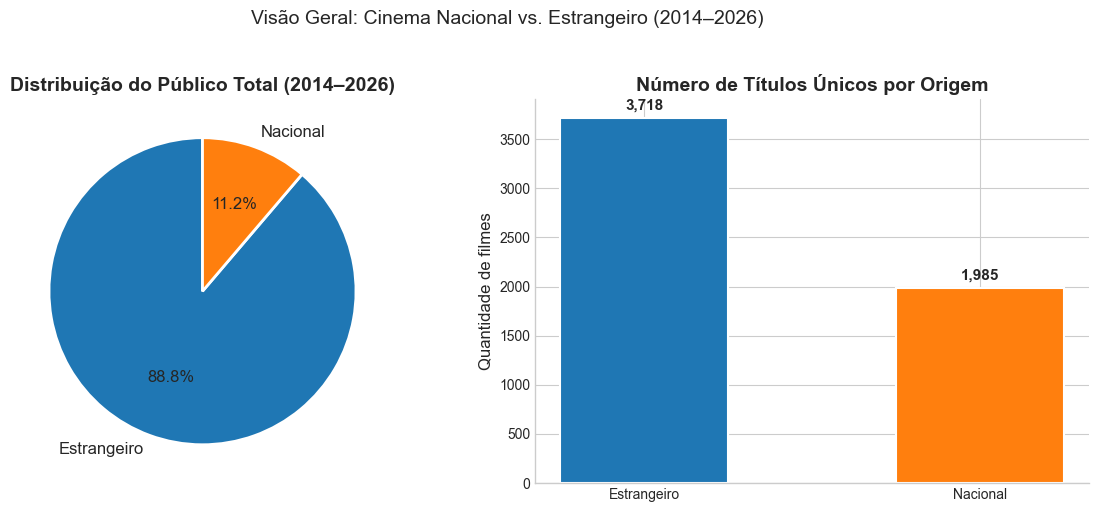

In [12]:
# ═══════════════════════════════════════════════════════════════
# 3.3 — DISTRIBUIÇÃO POR ORIGEM: NACIONAL vs. ESTRANGEIRO
# ═══════════════════════════════════════════════════════════════
# Visão geral da proporção entre cinema nacional e estrangeiro
# ao longo de todo o período.

por_origem = df.groupby('ORIGEM', observed=True)['PUBLICO'].agg(
    Total='sum', Registros='count'
).reset_index()

por_origem['Pct_Publico'] = por_origem['Total'] / por_origem['Total'].sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1: Distribuição de público total
axes[0].pie(
    por_origem['Total'],
    labels=por_origem['ORIGEM'],
    colors=[CORES['nacional'], CORES['estrangeiro']],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12},
)
axes[0].set_title('Distribuição do Público Total (2014–2026)', fontweight='bold')

# Gráfico 2: Número de filmes únicos por origem
filmes_por_origem = df.groupby('ORIGEM', observed=True)['TITULO_ORIGINAL'].nunique()
bars = axes[1].bar(
    filmes_por_origem.index,
    filmes_por_origem.values,
    color=[CORES['nacional'], CORES['estrangeiro']],
    edgecolor='white',
    linewidth=1.5,
    width=0.5,
)
# Adicionar rótulos de valor sobre as barras
for bar, val in zip(bars, filmes_por_origem.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f'{val:,}',
        ha='center', va='bottom', fontweight='bold', fontsize=11,
    )
axes[1].set_title('Número de Títulos Únicos por Origem', fontweight='bold')
axes[1].set_ylabel('Quantidade de filmes')
axes[1].set_xlabel('')

plt.suptitle('Visão Geral: Cinema Nacional vs. Estrangeiro (2014–2026)', fontsize=14, y=1.02)
plt.tight_layout()
salvar_figura('00_visao_geral_origem.png')
plt.show()

> **Leitura do gráfico:** Compara a fatia de público controlada pelo cinema nacional e estrangeiro com o número de títulos lançados por cada um — evidenciando que, apesar de o cinema estrangeiro ter muito mais títulos em cartaz, a disparidade de público é ainda maior, sinal de concentração de bilheteria em poucos lançamentos internacionais de grande escala.

---
## Seção 4 — Evolução Temporal do Mercado (2014–2026)

Visão macro da evolução do público de cinema no Brasil ao longo de mais de uma
década. Os gráficos mostram tanto a série mensal completa quanto os totais anuais,
já evidenciando o colapso de 2020 e a trajetória de recuperação posterior.

> **Atenção — 2026 incompleto:** o ano de 2026 tem dados apenas de janeiro a junho.
> Nos gráficos anuais, 2026 aparece em cinza com a nota `(jan–jun)` para deixar
> claro que não é comparável aos anos anteriores.

Figura salva: outputs/figures/01_publico_mensal_historico.png


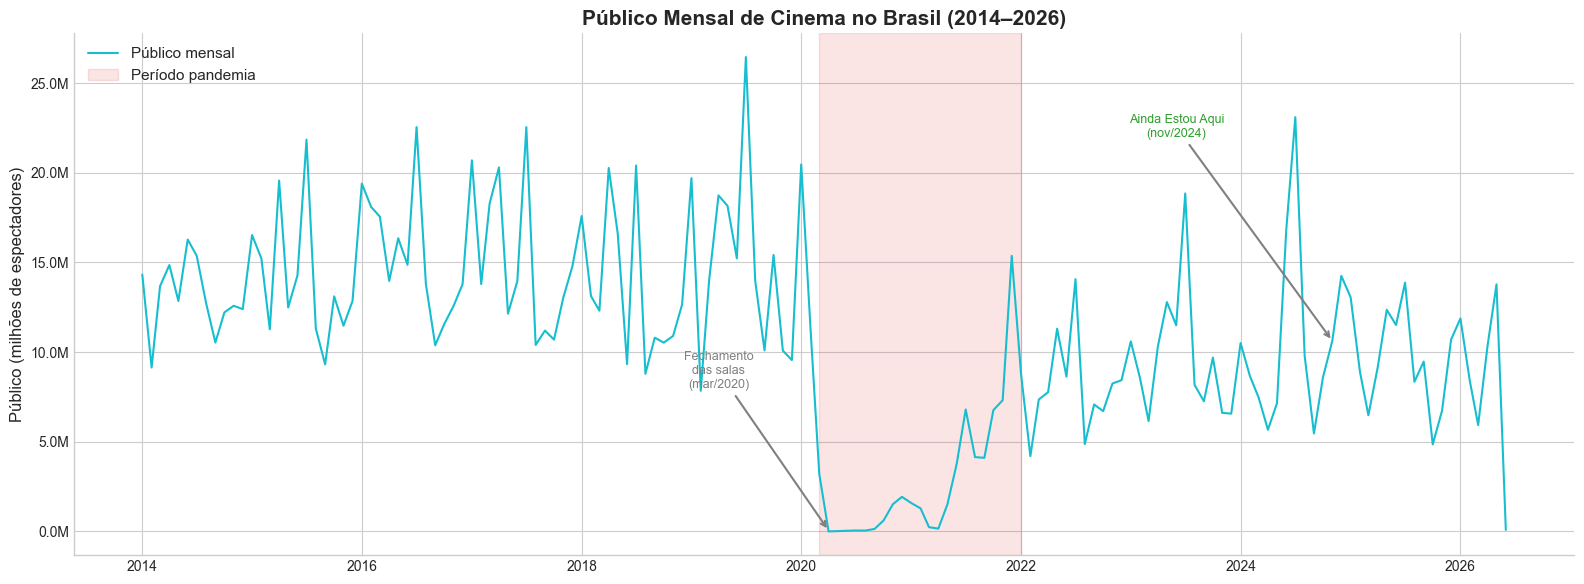

Série mensal salva.


In [13]:
# ═══════════════════════════════════════════════════════════════
# 4.1 — SÉRIE TEMPORAL MENSAL (2014–2026)
# ═══════════════════════════════════════════════════════════════
# Agregar público total por mês
publico_mensal = (
    df.groupby('ANO_MES', observed=True)['PUBLICO']
      .sum()
      .reset_index()
)
# Converter Period para timestamp para compatibilidade com matplotlib
publico_mensal['DATA'] = publico_mensal['ANO_MES'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(
    publico_mensal['DATA'],
    publico_mensal['PUBLICO'],
    color=CORES['total'],
    linewidth=1.5,
    label='Público mensal',
)

# Destacar o período de pandemia com fundo vermelho translúcido
# Cinemas fecharam em março/2020 e reabriram gradualmente até 2022
import pandas as pd
ax.axvspan(
    pd.Timestamp('2020-03-01'),
    pd.Timestamp('2021-12-31'),
    alpha=0.12, color=CORES['pandemia'], label='Período pandemia',
)

# Anotações dos eventos mais importantes
ax.annotate(
    'Fechamento\ndas salas\n(mar/2020)',
    xy=(pd.Timestamp('2020-04-01'), 50_000),
    xytext=(pd.Timestamp('2019-04-01'), 8_000_000),
    arrowprops=dict(arrowstyle='->', color='gray', lw=1.5),
    fontsize=9, color='gray', ha='center',
)
ax.annotate(
    'Ainda Estou Aqui\n(nov/2024)',
    xy=(pd.Timestamp('2024-11-01'), publico_mensal.loc[
        publico_mensal['ANO_MES'] == pd.Period('2024-11', 'M'), 'PUBLICO'
    ].values[0]),
    xytext=(pd.Timestamp('2023-06-01'), 22_000_000),
    arrowprops=dict(arrowstyle='->', color='gray', lw=1.5),
    fontsize=9, color=CORES['destaque'], ha='center',
)

# Eixo Y em milhões
ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatar_milhoes))
ax.set_title('Público Mensal de Cinema no Brasil (2014–2026)', fontweight='bold', fontsize=15)
ax.set_xlabel('')
ax.set_ylabel('Público (milhões de espectadores)')
ax.legend(loc='upper left')

plt.tight_layout()
salvar_figura('01_publico_mensal_historico.png')
plt.show()

# Salvar série mensal
publico_mensal[['ANO_MES', 'PUBLICO']].to_csv(
    OUTPUT_DATA_DIR / 'publico_mensal.csv', index=False
)
print('Série mensal salva.')

> **Leitura do gráfico:** Mostra a série mensal completa de público desde 2014, com o período sem exibições durante o fechamento das salas em 2020–2021 destacado em vermelho, e o pico recente puxado pela estreia de *Ainda Estou Aqui* em novembro de 2024.

Figura salva: outputs/figures/02_publico_anual.png


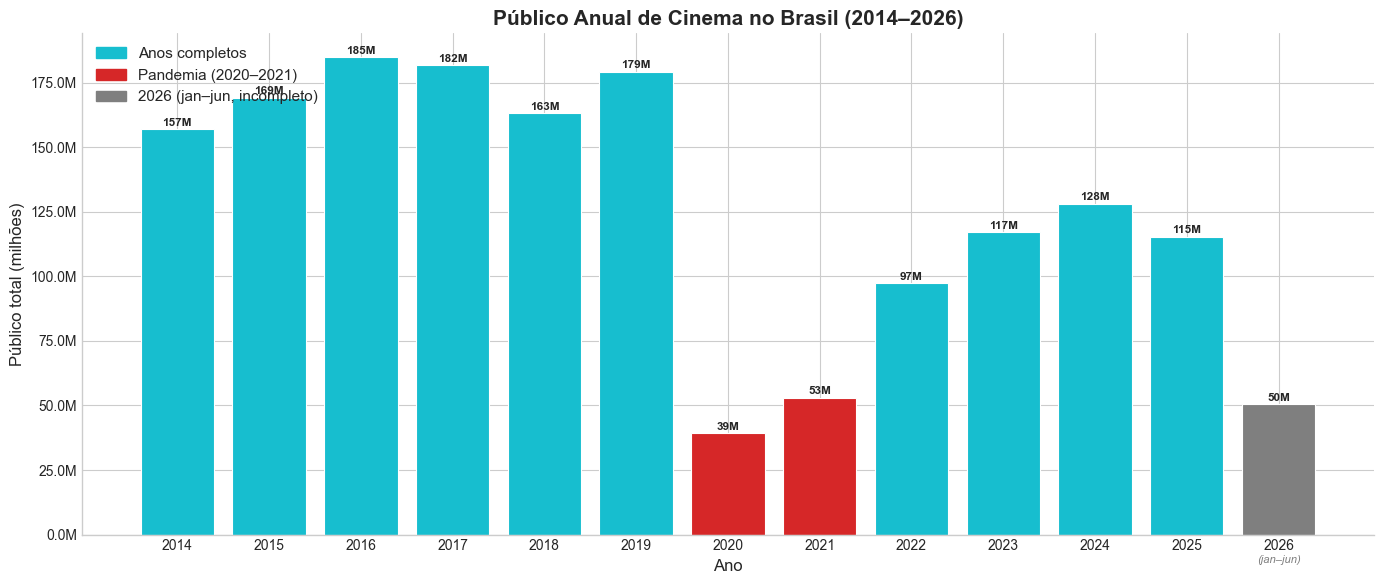

In [14]:
# ═══════════════════════════════════════════════════════════════
# 4.2 — PÚBLICO ANUAL (BARRAS)
# ═══════════════════════════════════════════════════════════════
# Agregar por ano. 2026 fica separado visualmente por ser incompleto.
publico_anual = df.groupby('ANO', observed=True)['PUBLICO'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))

# Cor diferente para 2026 (ano incompleto) e para 2020-2021 (pandemia)
cores_barras = []
for ano in publico_anual['ANO']:
    if ano == 2026:
        cores_barras.append(CORES['neutro'])
    elif ano in (2020, 2021):
        cores_barras.append(CORES['pandemia'])
    else:
        cores_barras.append(CORES['total'])

bars = ax.bar(
    publico_anual['ANO'].astype(str),
    publico_anual['PUBLICO'],
    color=cores_barras,
    edgecolor='white',
    linewidth=0.8,
)

# Rótulo de valor sobre cada barra (em milhões)
for bar, val in zip(bars, publico_anual['PUBLICO']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500_000,
        f'{val/1_000_000:.0f}M',
        ha='center', va='bottom', fontsize=8.5, fontweight='bold',
    )

# Rótulo especial para 2026 indicando que é parcial
idx_2026 = publico_anual[publico_anual['ANO'] == 2026].index
if len(idx_2026) > 0:
    bar_2026 = bars[idx_2026[0]]
    ax.text(
        bar_2026.get_x() + bar_2026.get_width() / 2,
        -8_000_000,
        '(jan–jun)',
        ha='center', va='top', fontsize=8, color=CORES['neutro'], style='italic',
    )

# Legenda manual das cores
from matplotlib.patches import Patch
legenda = [
    Patch(color=CORES['total'],   label='Anos completos'),
    Patch(color=CORES['pandemia'], label='Pandemia (2020–2021)'),
    Patch(color=CORES['neutro'],   label='2026 (jan–jun, incompleto)'),
]
ax.legend(handles=legenda, loc='upper left')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatar_milhoes))
ax.set_title('Público Anual de Cinema no Brasil (2014–2026)', fontweight='bold', fontsize=15)
ax.set_xlabel('Ano')
ax.set_ylabel('Público total (milhões)')

plt.tight_layout()
salvar_figura('02_publico_anual.png')
plt.show()

> **Leitura do gráfico:** Consolida a série mensal em totais anuais, destacando em vermelho os anos de pandemia (2020–2021) e em cinza 2026, que é parcial (apenas janeiro a junho) e não deve ser comparado diretamente aos anos completos.

---
## Seção 5 — Impacto da Pandemia de COVID-19

A pandemia de COVID-19 causou o colapso mais abrupto já registrado no mercado
cinematográfico brasileiro. Em março de 2020, os cinemas foram fechados por
determinação do governo. Entre abril e agosto de 2020, praticamente não houve
exibições — os poucos registros correspondem a Estados que reabriram antes.

Esta seção analisa a magnitude da queda e a velocidade de recuperação mensal,
comparando o período 2019–2022 contra o baseline pré-pandemia.

Figura salva: outputs/figures/03_impacto_covid.png


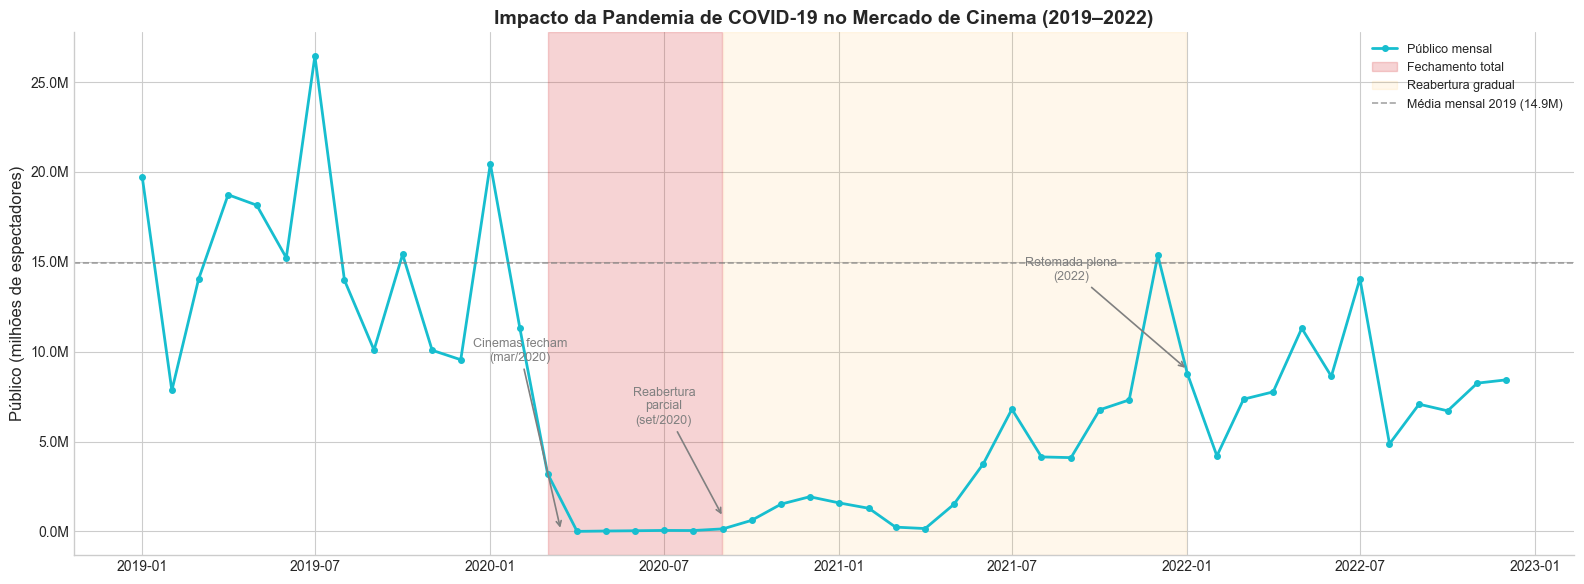

In [15]:
# ═══════════════════════════════════════════════════════════════
# 5.1 — ZOOM NO PERÍODO 2019–2022
# ═══════════════════════════════════════════════════════════════
import pandas as pd

# Filtrar apenas o período de interesse para a análise da pandemia
periodo_covid = publico_mensal[
    (publico_mensal['DATA'] >= '2019-01-01') &
    (publico_mensal['DATA'] <= '2022-12-31')
].copy()

fig, ax = plt.subplots(figsize=(16, 6))

# Linha do público mensal
ax.plot(
    periodo_covid['DATA'],
    periodo_covid['PUBLICO'],
    color=CORES['total'],
    linewidth=2,
    marker='o', markersize=4,
    label='Público mensal',
)

# Área sombreada: período de fechamento total (mar–ago/2020)
ax.axvspan(
    pd.Timestamp('2020-03-01'), pd.Timestamp('2020-08-31'),
    alpha=0.2, color=CORES['pandemia'], label='Fechamento total',
)
# Área sombreada: reabertura parcial (set/2020–dez/2021)
ax.axvspan(
    pd.Timestamp('2020-09-01'), pd.Timestamp('2021-12-31'),
    alpha=0.08, color='orange', label='Reabertura gradual',
)

# Linha de referência: média mensal de 2019 (baseline pré-pandemia)
media_2019 = publico_mensal[
    publico_mensal['ANO_MES'].dt.year == 2019
]['PUBLICO'].mean()
ax.axhline(
    media_2019, color='gray', linestyle='--', linewidth=1.2, alpha=0.7,
    label=f'Média mensal 2019 ({media_2019/1_000_000:.1f}M)',
)

# Anotações dos marcos principais
anotacoes = [
    ('2020-03-15', 50_000,   '2020-02-01', 9_500_000,  'Cinemas fecham\n(mar/2020)'),
    ('2020-09-01', 800_000,  '2020-07-01', 6_000_000,  'Reabertura\nparcial\n(set/2020)'),
    ('2022-01-01', 9_000_000,'2021-09-01', 14_000_000, 'Retomada plena\n(2022)'),
]
for xp, yp, xt, yt, texto in anotacoes:
    ax.annotate(
        texto,
        xy=(pd.Timestamp(xp), yp),
        xytext=(pd.Timestamp(xt), yt),
        arrowprops=dict(arrowstyle='->', color='gray', lw=1.2),
        fontsize=9, color='gray', ha='center',
    )

ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatar_milhoes))
ax.set_title('Impacto da Pandemia de COVID-19 no Mercado de Cinema (2019–2022)',
             fontweight='bold', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('Público (milhões de espectadores)')
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
salvar_figura('03_impacto_covid.png')
plt.show()

> **Leitura do gráfico:** Detalha o período 2019–2022 mês a mês frente à média mensal de 2019 (linha tracejada), permitindo visualizar tanto o fechamento total das salas quanto a velocidade da reabertura gradual.

In [16]:
# ═══════════════════════════════════════════════════════════════
# 5.2 — MÉTRICAS QUANTITATIVAS DA QUEDA
# ═══════════════════════════════════════════════════════════════
# Comparar os totais anuais contra 2019 (baseline pré-pandemia)

pub_anual = df.groupby('ANO', observed=True)['PUBLICO'].sum()
baseline_2019 = pub_anual[2019]

print('Impacto da pandemia — público anual vs. 2019 (baseline):')
print(f'  2019 (baseline):  {baseline_2019:>12,.0f}')
print()
for ano in [2020, 2021, 2022]:
    pub = pub_anual[ano]
    variacao = (pub - baseline_2019) / baseline_2019 * 100
    print(f'  {ano}: {pub:>12,.0f}  ({variacao:+.1f}% vs 2019)')

# Mês com menor público em toda a série histórica
mes_min = publico_mensal.loc[publico_mensal['PUBLICO'].idxmin()]
print()
print(f'Mês com menor público na série histórica:')
print(f'  {mes_min["ANO_MES"]}  →  {mes_min["PUBLICO"]:,.0f} espectadores')

# Salvar tabela de métricas da queda
queda = pd.DataFrame({
    'ANO': [2019, 2020, 2021, 2022],
    'PUBLICO': [pub_anual[a] for a in [2019, 2020, 2021, 2022]],
})
queda['VAR_PCT_VS_2019'] = (queda['PUBLICO'] - baseline_2019) / baseline_2019 * 100
queda.to_csv(OUTPUT_DATA_DIR / 'queda_pandemia.csv', index=False)
print('\nTabela salva em outputs/processados/queda_pandemia.csv')

Impacto da pandemia — público anual vs. 2019 (baseline):
  2019 (baseline):   179,262,678

  2020:   39,350,742  (-78.0% vs 2019)
  2021:   53,024,171  (-70.4% vs 2019)
  2022:   97,441,820  (-45.6% vs 2019)

Mês com menor público na série histórica:
  2020-04  →  1,648 espectadores

Tabela salva em outputs/processados/queda_pandemia.csv


---
## Seção 6 — Recuperação do Mercado Pós-Pandemia

Com os cinemas reabrindo gradualmente a partir de 2022, o mercado entrou em
trajetória de recuperação. Mas recuperar o público pré-pandemia levou tempo:
a combinação de hábitos alterados (streaming), crise econômica e ausência de
grandes lançamentos nos primeiros anos pós-pandemia fez a recuperação ser lenta.

> **Nota metodológica:** 2026 é excluído desta análise por ser incompleto
> (apenas jan–jun). Incluí-lo distorceria a comparação com anos completos.

Figura salva: outputs/figures/04_recuperacao_pos_pandemia.png


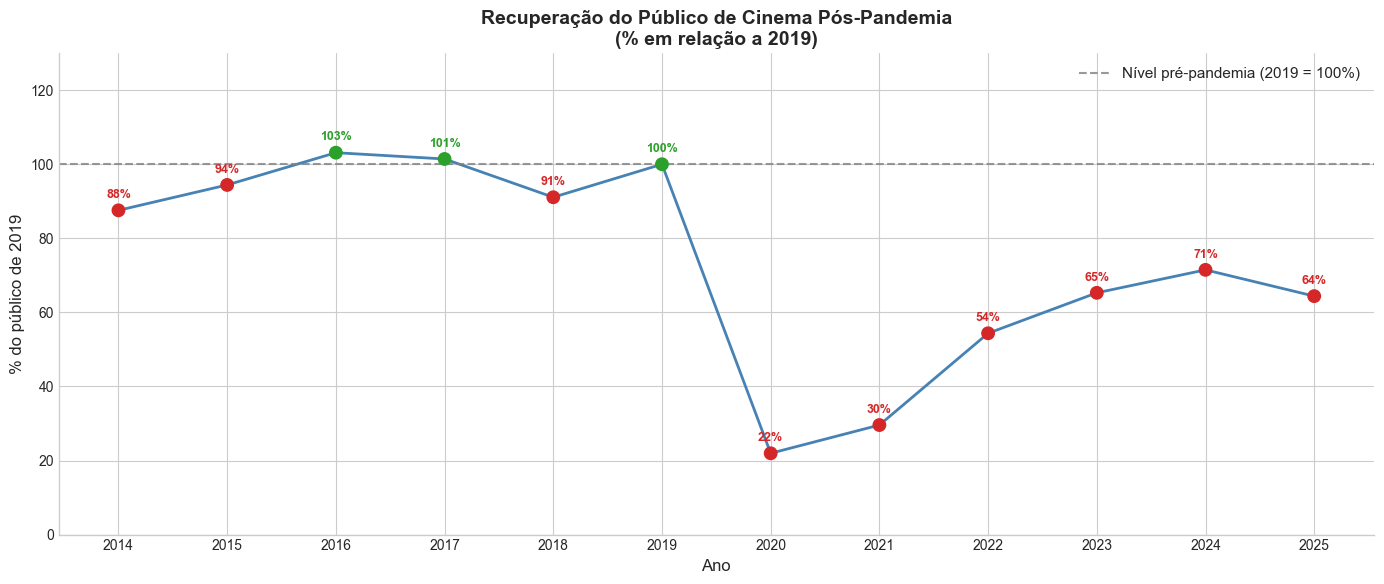

Recuperação em relação a 2019:
  2014:   87.6%  — 12pp abaixo
  2015:   94.4%  — 6pp abaixo
  2016:  103.1%  — ✓ recuperado
  2017:  101.4%  — ✓ recuperado
  2018:   91.1%  — 9pp abaixo
  2019:  100.0%  — ✓ recuperado
  2020:   22.0%  — 78pp abaixo
  2021:   29.6%  — 70pp abaixo
  2022:   54.4%  — 46pp abaixo
  2023:   65.3%  — 35pp abaixo
  2024:   71.5%  — 29pp abaixo
  2025:   64.4%  — 36pp abaixo


In [17]:
# ═══════════════════════════════════════════════════════════════
# 6.1 — TRAJETÓRIA DE RECUPERAÇÃO (2019–2025)
# ═══════════════════════════════════════════════════════════════
# Usar apenas anos completos para comparação justa
anos_completos = df[df['ANO_COMPLETO']].groupby('ANO', observed=True)['PUBLICO'].sum()

# Calcular % de recuperação em relação ao baseline 2019
baseline = anos_completos[2019]
pct_recuperacao = (anos_completos / baseline * 100).reset_index()
pct_recuperacao.columns = ['ANO', 'PCT']

fig, ax = plt.subplots(figsize=(14, 6))

# Colorir os pontos: abaixo de 100% = vermelho, acima = verde
cores_pontos = [
    CORES['pandemia'] if pct < 100 else CORES['destaque']
    for pct in pct_recuperacao['PCT']
]

ax.plot(
    pct_recuperacao['ANO'].astype(str),
    pct_recuperacao['PCT'],
    color='steelblue', linewidth=2, zorder=2,
)
ax.scatter(
    pct_recuperacao['ANO'].astype(str),
    pct_recuperacao['PCT'],
    color=cores_pontos, s=80, zorder=3,
)

# Linha de referência em 100% (nível pré-pandemia)
ax.axhline(100, color='gray', linestyle='--', linewidth=1.5, alpha=0.8,
           label='Nível pré-pandemia (2019 = 100%)')

# Rótulo com o percentual em cada ponto
for _, row in pct_recuperacao.iterrows():
    ax.text(
        str(int(row['ANO'])),
        row['PCT'] + 2.5,
        f'{row["PCT"]:.0f}%',
        ha='center', va='bottom', fontsize=9, fontweight='bold',
        color=CORES['pandemia'] if row['PCT'] < 100 else CORES['destaque'],
    )

ax.set_ylim(0, 130)
ax.set_title('Recuperação do Público de Cinema Pós-Pandemia\n(% em relação a 2019)',
             fontweight='bold', fontsize=14)
ax.set_xlabel('Ano')
ax.set_ylabel('% do público de 2019')
ax.legend()

plt.tight_layout()
salvar_figura('04_recuperacao_pos_pandemia.png')
plt.show()

# Imprimir resumo
print('Recuperação em relação a 2019:')
for _, row in pct_recuperacao.iterrows():
    status = '✓ recuperado' if row['PCT'] >= 100 else f'{100 - row["PCT"]:.0f}pp abaixo'
    print(f'  {int(row["ANO"])}: {row["PCT"]:6.1f}%  — {status}')

Figura salva: outputs/figures/04b_top10_nacionais_pos_reabertura.png


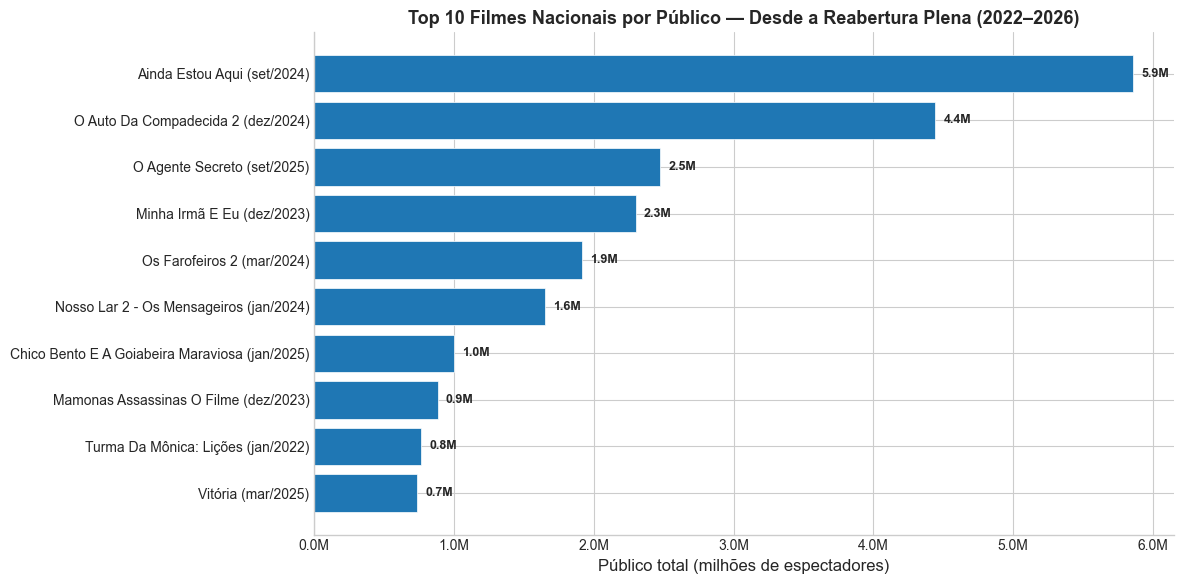

In [18]:
# ═══════════════════════════════════════════════════════════════
# 6.2 — TOP 10 FILMES NACIONAIS DESDE A REABERTURA PLENA (2022–2026)
# ═══════════════════════════════════════════════════════════════
top_nacionais_pos_reabertura = (
    df[(df['ORIGEM'] == 'Nacional') & (df['ANO'] >= 2022)]
      .groupby('TITULO_ORIGINAL', observed=True)
      .agg(Público=('PUBLICO', 'sum'), Estreia=('DATA_EXIBICAO', 'min'))
      .sort_values('Público', ascending=False)
      .head(10)
      .reset_index()
)
top_nacionais_pos_reabertura.columns = ['Título', 'Público', 'Estreia']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    range(len(top_nacionais_pos_reabertura)),
    top_nacionais_pos_reabertura['Público'],
    color=CORES['nacional'], edgecolor='white', linewidth=0.5,
)
for bar, val in zip(bars, top_nacionais_pos_reabertura['Público']):
    ax.text(bar.get_width() + top_nacionais_pos_reabertura['Público'].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val/1_000_000:.1f}M', va='center', fontsize=9, fontweight='bold')

titulos_fmt = [
    f"{t.title()} ({MESES_PT[d.month].lower()}/{d.year})"
    for t, d in zip(top_nacionais_pos_reabertura['Título'], top_nacionais_pos_reabertura['Estreia'])
]
ax.set_yticks(range(len(top_nacionais_pos_reabertura)))
ax.set_yticklabels(titulos_fmt, fontsize=10)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(formatar_milhoes))
ax.set_title('Top 10 Filmes Nacionais por Público — Desde a Reabertura Plena (2022–2026)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Público total (milhões de espectadores)')

plt.tight_layout()
salvar_figura('04b_top10_nacionais_pos_reabertura.png')
plt.show()

> **Leitura do gráfico:** Ranqueia os filmes nacionais de maior público considerando apenas o período de retomada plena (2022 em diante), mostrando quais produções brasileiras sustentaram a recuperação do mercado após a pandemia.

Figura salva: outputs/figures/04c_top10_estrangeiros_pos_reabertura.png


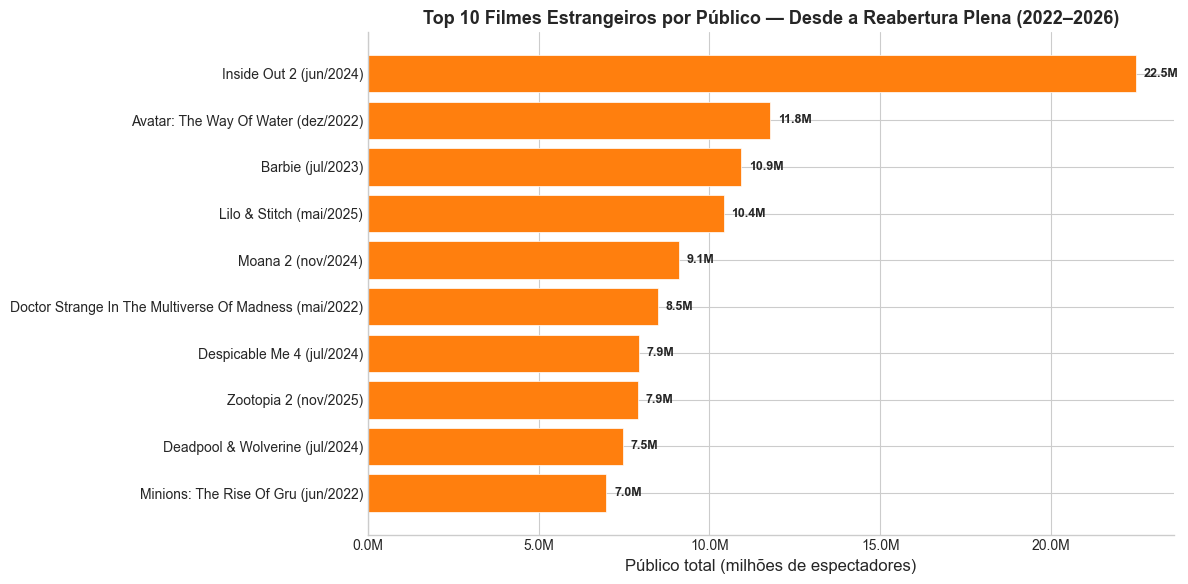

In [19]:
# ═══════════════════════════════════════════════════════════════
# 6.3 — TOP 10 FILMES ESTRANGEIROS DESDE A REABERTURA PLENA (2022–2026)
# ═══════════════════════════════════════════════════════════════
top_estrangeiros_pos_reabertura = (
    df[(df['ORIGEM'] == 'Estrangeiro') & (df['ANO'] >= 2022)]
      .groupby('TITULO_ORIGINAL', observed=True)
      .agg(Público=('PUBLICO', 'sum'), Estreia=('DATA_EXIBICAO', 'min'))
      .sort_values('Público', ascending=False)
      .head(10)
      .reset_index()
)
top_estrangeiros_pos_reabertura.columns = ['Título', 'Público', 'Estreia']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    range(len(top_estrangeiros_pos_reabertura)),
    top_estrangeiros_pos_reabertura['Público'],
    color=CORES['estrangeiro'], edgecolor='white', linewidth=0.5,
)
for bar, val in zip(bars, top_estrangeiros_pos_reabertura['Público']):
    ax.text(bar.get_width() + top_estrangeiros_pos_reabertura['Público'].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val/1_000_000:.1f}M', va='center', fontsize=9, fontweight='bold')

titulos_fmt = [
    f"{t.title()} ({MESES_PT[d.month].lower()}/{d.year})"
    for t, d in zip(top_estrangeiros_pos_reabertura['Título'], top_estrangeiros_pos_reabertura['Estreia'])
]
ax.set_yticks(range(len(top_estrangeiros_pos_reabertura)))
ax.set_yticklabels(titulos_fmt, fontsize=10)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(formatar_milhoes))
ax.set_title('Top 10 Filmes Estrangeiros por Público — Desde a Reabertura Plena (2022–2026)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Público total (milhões de espectadores)')

plt.tight_layout()
salvar_figura('04c_top10_estrangeiros_pos_reabertura.png')
plt.show()

> **Leitura do gráfico:** Ranqueia os filmes estrangeiros de maior público desde 2022, permitindo comparar o perfil de lançamentos que impulsionaram a retomada do público estrangeiro frente ao recorte nacional da subseção anterior.

---
## Seção 7 — Cinema Nacional vs. Estrangeiro

O mercado cinematográfico brasileiro é historicamente dominado por produções
estrangeiras — em especial americanas, que respondem por mais de 90% do público
estrangeiro. A participação do cinema nacional oscila bastante de ano para ano,
sendo fortemente influenciada por poucos filmes de grande bilheteria.

Esta seção analisa:
1. A evolução do **market share** do cinema nacional ao longo do tempo
2. Os **top 10 filmes** mais assistidos em cada categoria
3. A **dominância americana** no segmento estrangeiro

Figura salva: outputs/figures/05_market_share_nacional_estrangeiro.png


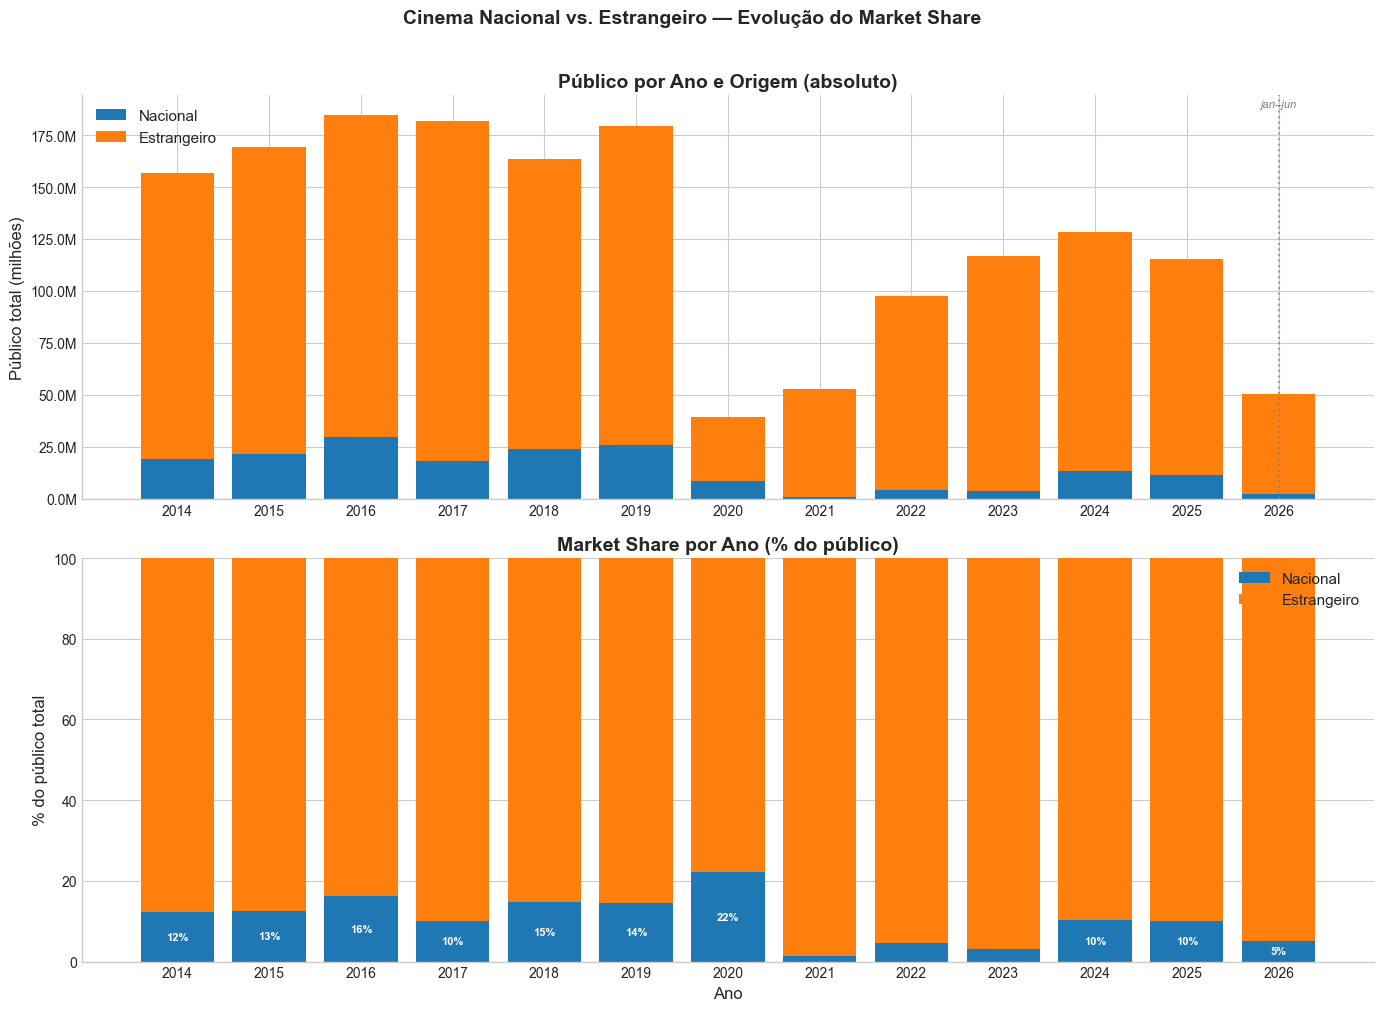

Market share salvo em outputs/processados/market_share_anual.csv


In [20]:
# ═══════════════════════════════════════════════════════════════
# 7.1 — MARKET SHARE ANUAL: NACIONAL vs. ESTRANGEIRO
# ═══════════════════════════════════════════════════════════════
# Agregar público por ano e origem
share_anual = (
    df.groupby(['ANO', 'ORIGEM'], observed=True)['PUBLICO']
      .sum()
      .unstack('ORIGEM')
      .fillna(0)
)

# Calcular percentual de cada origem no total do ano
share_pct = share_anual.div(share_anual.sum(axis=1), axis=0) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# ── Gráfico superior: barras empilhadas (público absoluto) ────
anos = share_anual.index.astype(str)
ax1.bar(anos, share_anual['Nacional'],    color=CORES['nacional'],    label='Nacional')
ax1.bar(anos, share_anual['Estrangeiro'], color=CORES['estrangeiro'], label='Estrangeiro',
        bottom=share_anual['Nacional'])

# Destacar 2026 como parcial
ax1.axvline(x=len(anos) - 1, color=CORES['neutro'], linestyle=':', linewidth=1.5, alpha=0.7)
ax1.text(len(anos) - 1, share_anual.sum(axis=1).max() * 1.02,
         'jan–jun', ha='center', fontsize=8, color=CORES['neutro'], style='italic')

ax1.yaxis.set_major_formatter(mticker.FuncFormatter(formatar_milhoes))
ax1.set_title('Público por Ano e Origem (absoluto)', fontweight='bold')
ax1.set_ylabel('Público total (milhões)')
ax1.legend(loc='upper left')
ax1.set_xlabel('')

# ── Gráfico inferior: barras empilhadas (percentual 100%) ─────
ax2.bar(anos, share_pct['Nacional'],    color=CORES['nacional'],    label='Nacional')
ax2.bar(anos, share_pct['Estrangeiro'], color=CORES['estrangeiro'], label='Estrangeiro',
        bottom=share_pct['Nacional'])

# Rótulo do percentual nacional em cada barra
for i, (ano, row) in enumerate(share_pct.iterrows()):
    pct_nac = row['Nacional']
    if pct_nac >= 5:  # só exibir rótulo se houver espaço
        ax2.text(i, pct_nac / 2, f'{pct_nac:.0f}%',
                 ha='center', va='center', fontsize=8,
                 color='white', fontweight='bold')

ax2.set_ylim(0, 100)
ax2.set_title('Market Share por Ano (% do público)', fontweight='bold')
ax2.set_ylabel('% do público total')
ax2.set_xlabel('Ano')
ax2.legend(loc='upper right')

plt.suptitle('Cinema Nacional vs. Estrangeiro — Evolução do Market Share',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
salvar_figura('05_market_share_nacional_estrangeiro.png')
plt.show()

# Salvar para dashboard
share_out = share_anual.copy()
share_out['pct_nacional']    = share_pct['Nacional']
share_out['pct_estrangeiro'] = share_pct['Estrangeiro']
share_out.to_csv(OUTPUT_DATA_DIR / 'market_share_anual.csv')
print('Market share salvo em outputs/processados/market_share_anual.csv')

> **Leitura do gráfico:** Compara a evolução do público absoluto por origem com a evolução do market share percentual ano a ano, evidenciando os anos em que o cinema nacional teve picos de participação puxados por lançamentos de grande público.

Figura salva: outputs/figures/06_top10_filmes_nacionais.png


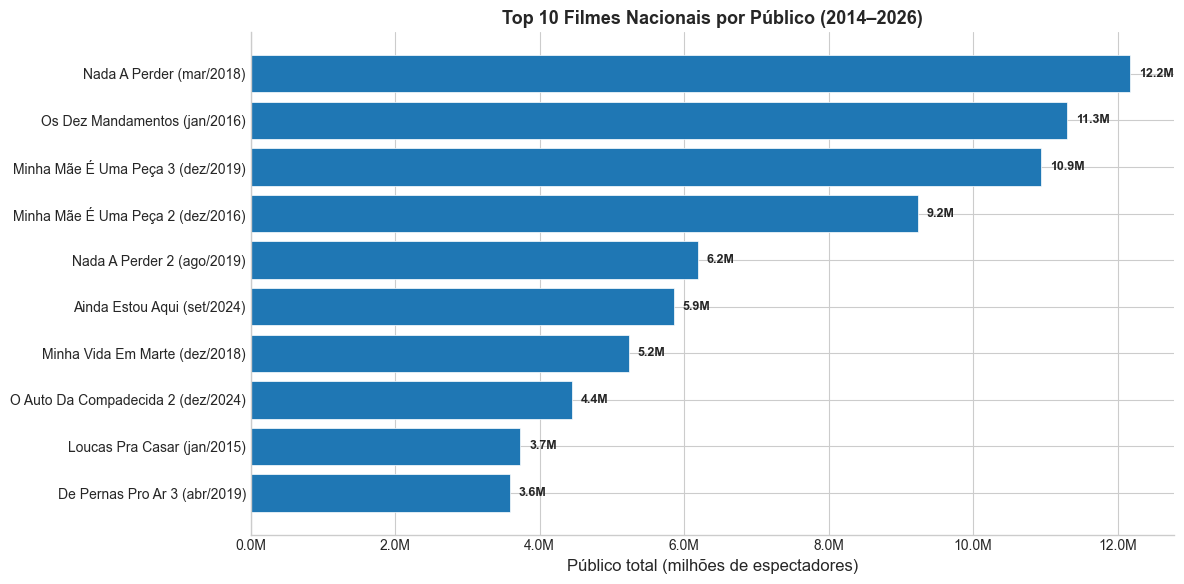

In [21]:
# ═══════════════════════════════════════════════════════════════
# 7.2 — TOP 10 FILMES NACIONAIS (TODO O PERÍODO)
# ═══════════════════════════════════════════════════════════════
# Para identificar o título de exibição de cada filme, usamos
# TITULO_BRASIL (que foi preenchido com TITULO_ORIGINAL quando vazio).
# Agrupamos por TITULO_ORIGINAL para não contar versões do mesmo filme
# em separado caso o título em português tenha variado.

top_nacionais = (
    df[df['ORIGEM'] == 'Nacional']
      .groupby('TITULO_ORIGINAL', observed=True)
      .agg(Público=('PUBLICO', 'sum'), Estreia=('DATA_EXIBICAO', 'min'))
      .sort_values('Público', ascending=False)
      .head(10)
      .reset_index()
)
top_nacionais.columns = ['Título', 'Público', 'Estreia']

fig, ax = plt.subplots(figsize=(12, 6))

# Barras horizontais — mais fáceis de ler com títulos longos
bars = ax.barh(
    range(len(top_nacionais)),
    top_nacionais['Público'],
    color=CORES['nacional'],
    edgecolor='white', linewidth=0.5,
)

# Rótulo de valor ao lado de cada barra
for bar, val in zip(bars, top_nacionais['Público']):
    ax.text(
        bar.get_width() + top_nacionais['Público'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val/1_000_000:.1f}M',
        va='center', fontsize=9, fontweight='bold',
    )

# Títulos no eixo Y — capitalizar para leitura mais agradável
titulos_fmt = [
    f"{t.title()} ({MESES_PT[d.month].lower()}/{d.year})"
    for t, d in zip(top_nacionais['Título'], top_nacionais['Estreia'])
]
ax.set_yticks(range(len(top_nacionais)))
ax.set_yticklabels(titulos_fmt, fontsize=10)
ax.invert_yaxis()  # maior público no topo

ax.xaxis.set_major_formatter(mticker.FuncFormatter(formatar_milhoes))
ax.set_title('Top 10 Filmes Nacionais por Público (2014–2026)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Público total (milhões de espectadores)')

plt.tight_layout()
salvar_figura('06_top10_filmes_nacionais.png')
plt.show()

> **Leitura do gráfico:** Ranqueia os 10 filmes nacionais de maior público histórico, permitindo identificar quais produções brasileiras romperam a barreira de bilheteria de massa.

Figura salva: outputs/figures/07_top10_filmes_estrangeiros.png


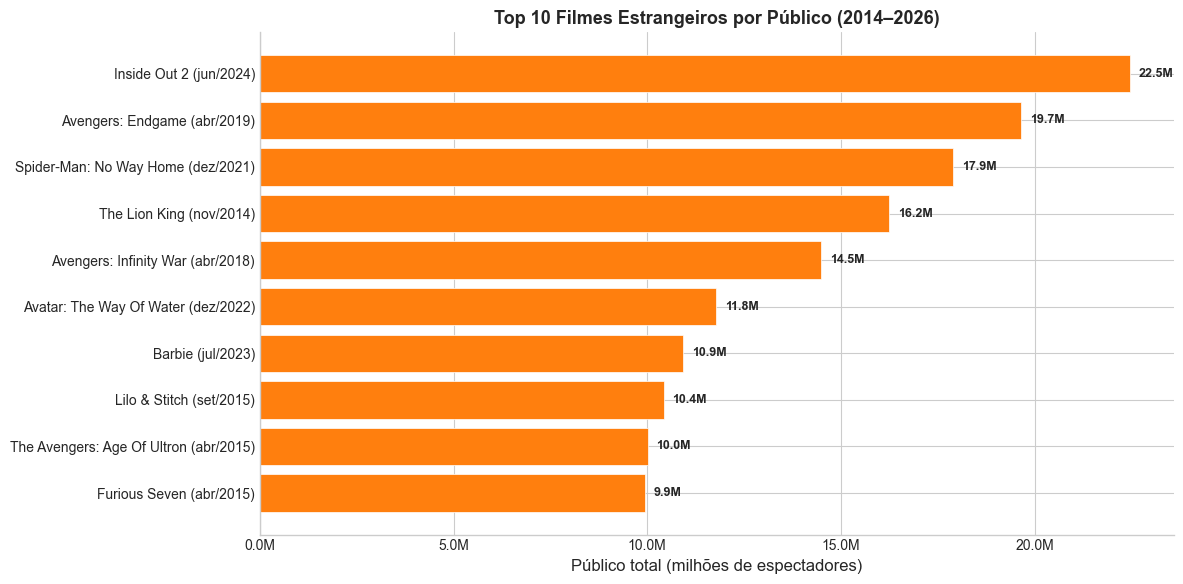

In [22]:
# ═══════════════════════════════════════════════════════════════
# 7.3 — TOP 10 FILMES ESTRANGEIROS (TODO O PERÍODO)
# ═══════════════════════════════════════════════════════════════
top_estrangeiros = (
    df[df['ORIGEM'] == 'Estrangeiro']
      .groupby('TITULO_ORIGINAL', observed=True)
      .agg(Público=('PUBLICO', 'sum'), Estreia=('DATA_EXIBICAO', 'min'))
      .sort_values('Público', ascending=False)
      .head(10)
      .reset_index()
)
top_estrangeiros.columns = ['Título', 'Público', 'Estreia']

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    range(len(top_estrangeiros)),
    top_estrangeiros['Público'],
    color=CORES['estrangeiro'],
    edgecolor='white', linewidth=0.5,
)
for bar, val in zip(bars, top_estrangeiros['Público']):
    ax.text(
        bar.get_width() + top_estrangeiros['Público'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val/1_000_000:.1f}M',
        va='center', fontsize=9, fontweight='bold',
    )

titulos_fmt = [
    f"{t.title()} ({MESES_PT[d.month].lower()}/{d.year})"
    for t, d in zip(top_estrangeiros['Título'], top_estrangeiros['Estreia'])
]
ax.set_yticks(range(len(top_estrangeiros)))
ax.set_yticklabels(titulos_fmt, fontsize=10)
ax.invert_yaxis()

ax.xaxis.set_major_formatter(mticker.FuncFormatter(formatar_milhoes))
ax.set_title('Top 10 Filmes Estrangeiros por Público (2014–2026)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Público total (milhões de espectadores)')

plt.tight_layout()
salvar_figura('07_top10_filmes_estrangeiros.png')
plt.show()

> **Leitura do gráfico:** Ranqueia os 10 filmes estrangeiros de maior público histórico — tipicamente grandes franquias de estúdios americanos, refletindo a dominância desse segmento no mercado brasileiro.

In [23]:
# ═══════════════════════════════════════════════════════════════
# 7.4 — DOMINÂNCIA AMERICANA NO SEGMENTO ESTRANGEIRO
# ═══════════════════════════════════════════════════════════════
# Dentro dos filmes estrangeiros, os EUA dominam de forma
# absolutamente esmagadora. Esta célula quantifica isso.

pub_por_pais = (
    df[df['ORIGEM'] == 'Estrangeiro']
      .groupby('PAIS_OBRA', observed=True)['PUBLICO']
      .sum()
      .sort_values(ascending=False)
)

total_estrangeiro = pub_por_pais.sum()
top5_paises = pub_por_pais.head(5)

print('Participação por país no público estrangeiro:')
for pais, pub in top5_paises.items():
    print(f'  {pais:<30s} {pub/1_000_000:>7.1f}M  ({pub/total_estrangeiro*100:.1f}%)')
outros = pub_por_pais.iloc[5:].sum()
print(f'  {"Demais países":<30s} {outros/1_000_000:>7.1f}M  ({outros/total_estrangeiro*100:.1f}%)')

# Salvar top filmes consolidado
top_todos = pd.concat([
    top_nacionais.assign(origem='Nacional'),
    top_estrangeiros.assign(origem='Estrangeiro'),
])
top_todos.to_csv(OUTPUT_DATA_DIR / 'top_filmes.csv', index=False)
print('\nTop filmes salvo em outputs/processados/top_filmes.csv')

Participação por país no público estrangeiro:
  ESTADOS UNIDOS                  1312.6M  (90.4%)
  CANADÁ                            44.6M  (3.1%)
  FRANÇA                            21.3M  (1.5%)
  CHINA, REPUBLICA POPULAR          16.0M  (1.1%)
  REINO UNIDO                        9.4M  (0.6%)
  Demais países                     48.4M  (3.3%)

Top filmes salvo em outputs/processados/top_filmes.csv


Figura salva: outputs/figures/07b_participacao_paises_estrangeiro.png


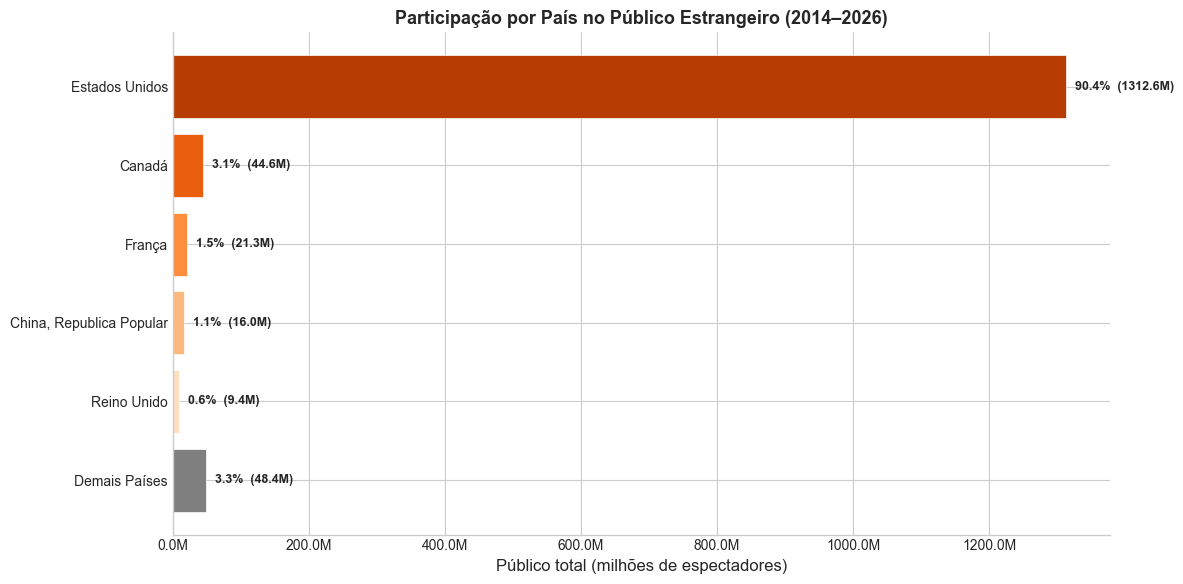

In [24]:
# ═══════════════════════════════════════════════════════════════
# 7.4b — GRÁFICO: PARTICIPAÇÃO POR PAÍS NO PÚBLICO ESTRANGEIRO
# ═══════════════════════════════════════════════════════════════
paises_labels = list(top5_paises.index) + ['Demais países']
paises_valores = list(top5_paises.values) + [outros]
paises_pct = [v / total_estrangeiro * 100 for v in paises_valores]

cores_paises = sns.color_palette('Oranges_r', len(top5_paises)) + [CORES['neutro']]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(len(paises_labels)), paises_valores,
               color=cores_paises, edgecolor='white', linewidth=0.5)

for bar, val, pct in zip(bars, paises_valores, paises_pct):
    ax.text(bar.get_width() + max(paises_valores) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%  ({val/1_000_000:.1f}M)',
            va='center', fontsize=9, fontweight='bold')

ax.set_yticks(range(len(paises_labels)))
ax.set_yticklabels([p.title() for p in paises_labels], fontsize=10)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(formatar_milhoes))
ax.set_title('Participação por País no Público Estrangeiro (2014–2026)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Público total (milhões de espectadores)')

plt.tight_layout()
salvar_figura('07b_participacao_paises_estrangeiro.png')
plt.show()

> **Leitura do gráfico:** Mostra como o público de filmes estrangeiros se distribui entre os principais países de origem, evidenciando o quanto os Estados Unidos concentram esse segmento frente aos demais países, agrupados em "Demais países".

---
## Seção 8 — Impacto de Filmes Premiados

Dois filmes brasileiros recentes acumularam prêmios internacionais de peso e
impactaram o mercado de formas distintas:

| Filme | Diretor | Estreia | Principais prêmios |
|-------|---------|---------|--------------------|
| **Ainda Estou Aqui** | Walter Salles | 07/11/2024 | Oscar 2025 (Melhor Filme Internacional — 1º brasileiro), Globo de Ouro (Fernanda Torres), Veneza 2024 (Melhor Roteiro) |
| **O Agente Secreto** | Kleber Mendonça Filho | nov/2025 | Cannes 2025 (Melhor Diretor + Melhor Ator — Wagner Moura), Oscar 2026 (4 indicações) |

Os dois filmes têm perfis muito diferentes em bilheteria:
*Ainda Estou Aqui* foi um fenômeno popular (~5–6 milhões de espectadores, 21 semanas
em cartaz), enquanto *O Agente Secreto* é um título mais autoral que atingiu
mais de 1 milhão de espectadores — expressivo para o segmento.

> **Sobre os dados de 2026:** *O Agente Secreto* estreou em novembro/2025 e pode
> ter ainda estado em cartaz em 2026. Os dados de jan–jun/2026 são parciais,
> portanto os totais do filme podem estar levemente subestimados.

In [25]:
# ═══════════════════════════════════════════════════════════════
# 8.1 — EXTRAÇÃO E VALIDAÇÃO DOS DADOS
# ═══════════════════════════════════════════════════════════════
# Os títulos nos dados ANCINE estão sempre em maiúsculas e sem variações
# de grafia — verificado na exploração inicial dos dados.

aea = df[df['TITULO_ORIGINAL'] == 'AINDA ESTOU AQUI'].copy()
oas = df[df['TITULO_ORIGINAL'] == 'O AGENTE SECRETO'].copy()

print('=== AINDA ESTOU AQUI ===')
print(f'  Registros (sala × dia):  {len(aea):>8,}')
print(f'  Público total:           {aea["PUBLICO"].sum():>8,}')
print(f'  Período em cartaz:       {aea["DATA_EXIBICAO"].min().date()}  →  {aea["DATA_EXIBICAO"].max().date()}')
print(f'  Salas únicas:            {aea["NOME_SALA"].nunique():>8,}')
print(f'  Estados cobertos:        {aea["UF_SALA_COMPLEXO"].nunique():>8,}')
print()
print('=== O AGENTE SECRETO ===')
print(f'  Registros (sala × dia):  {len(oas):>8,}')
print(f'  Público total:           {oas["PUBLICO"].sum():>8,}')
print(f'  Período em cartaz:       {oas["DATA_EXIBICAO"].min().date()}  →  {oas["DATA_EXIBICAO"].max().date()}')
print(f'  Salas únicas:            {oas["NOME_SALA"].nunique():>8,}')
print(f'  Estados cobertos:        {oas["UF_SALA_COMPLEXO"].nunique():>8,}')
print()
if len(oas[oas['ANO'] == 2026]) > 0:
    pub_2026 = oas[oas['ANO'] == 2026]['PUBLICO'].sum()
    print(f'  ⚠️  Público em 2026 (parcial, jan–jun): {pub_2026:,}')

=== AINDA ESTOU AQUI ===
  Registros (sala × dia):    82,732
  Público total:           5,857,612
  Período em cartaz:       2024-09-19  →  2026-04-12
  Salas únicas:               3,004
  Estados cobertos:              27

=== O AGENTE SECRETO ===
  Registros (sala × dia):    40,083
  Público total:           2,476,469
  Período em cartaz:       2025-09-10  →  2026-05-20
  Salas únicas:               2,467
  Estados cobertos:              27

  ⚠️  Público em 2026 (parcial, jan–jun): 1,388,140


Figura salva: outputs/figures/08_filmes_premiados_curvas.png


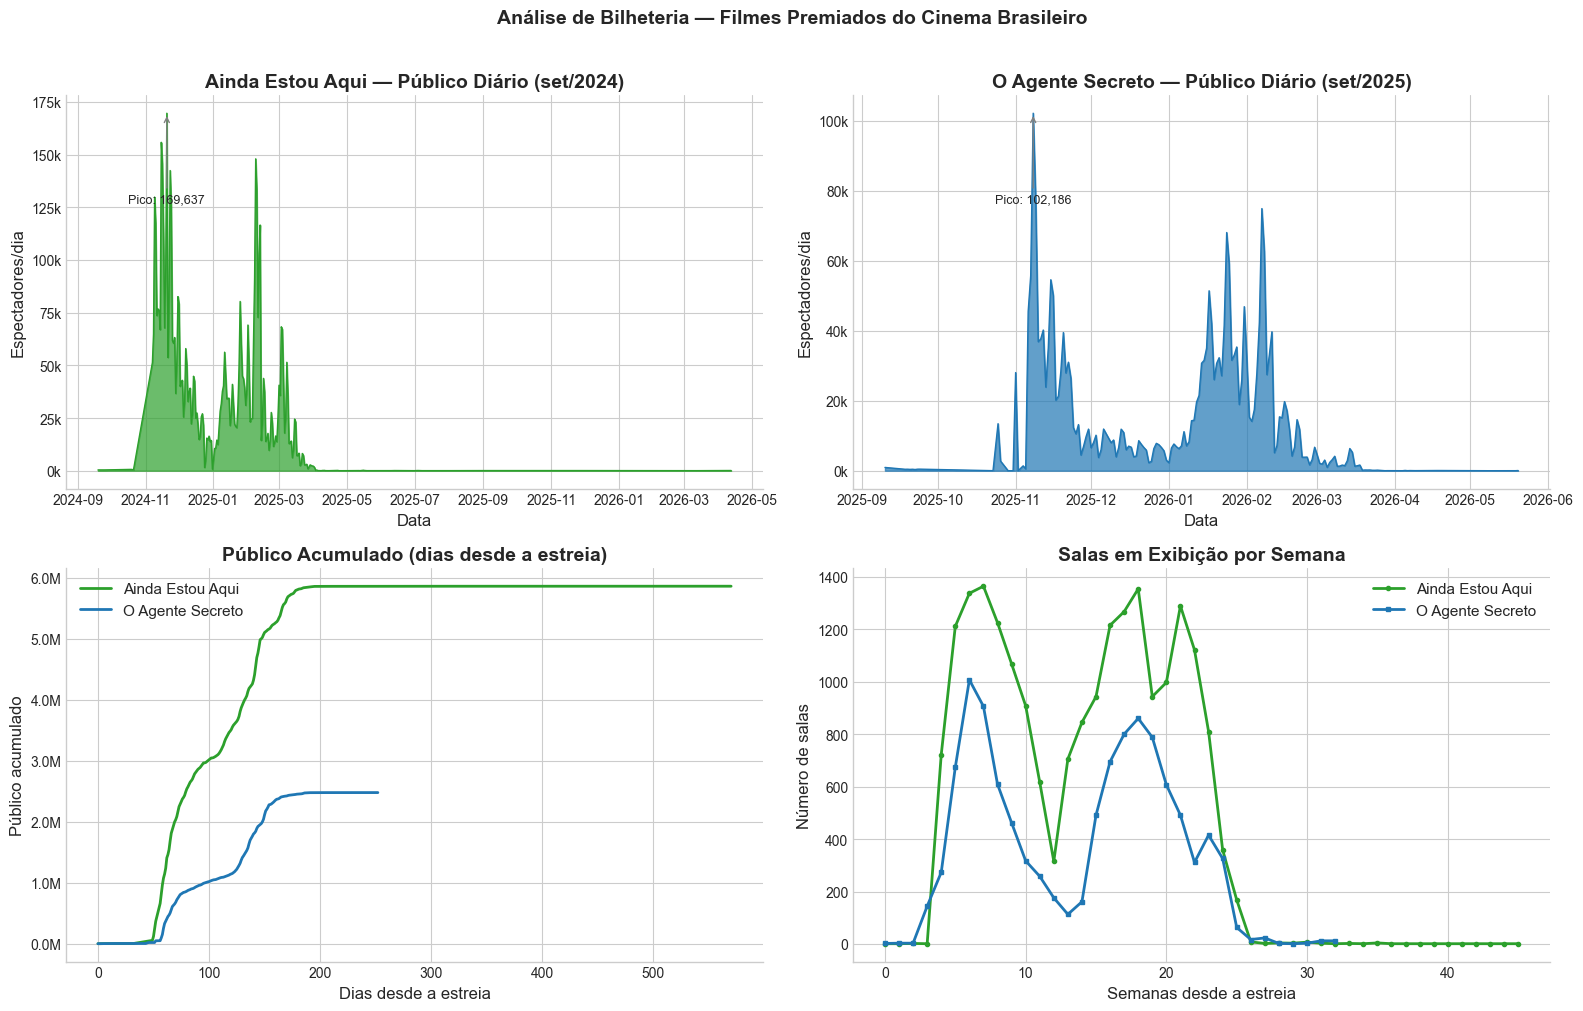

In [26]:
# ═══════════════════════════════════════════════════════════════
# 8.2 — CURVA DE PÚBLICO DIÁRIO
# ═══════════════════════════════════════════════════════════════
# Agregar o público total de cada filme por dia de exibição.
# Isso mostra o ritmo de crescimento, o pico e a curva de declínio
# — padrão típico de lançamento cinematográfico.

aea_diario = aea.groupby('DATA_EXIBICAO')['PUBLICO'].sum().reset_index()
oas_diario = oas.groupby('DATA_EXIBICAO')['PUBLICO'].sum().reset_index()

# Calcular dias desde a estreia (para alinhar as curvas na mesma escala)
aea_diario['DIA'] = (aea_diario['DATA_EXIBICAO'] - aea_diario['DATA_EXIBICAO'].min()).dt.days
oas_diario['DIA'] = (oas_diario['DATA_EXIBICAO'] - oas_diario['DATA_EXIBICAO'].min()).dt.days

# Calcular o público acumulado ao longo do tempo
aea_diario['PUBLICO_ACUM'] = aea_diario['PUBLICO'].cumsum()
oas_diario['PUBLICO_ACUM'] = oas_diario['PUBLICO'].cumsum()

# Mês/ano de estreia (primeira exibição em cartaz), para os títulos dos gráficos
estreia_aea = aea_diario['DATA_EXIBICAO'].min()
estreia_oas = oas_diario['DATA_EXIBICAO'].min()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── Público diário: Ainda Estou Aqui ─────────────────────────
axes[0, 0].fill_between(
    aea_diario['DATA_EXIBICAO'], aea_diario['PUBLICO'],
    color=CORES['destaque'], alpha=0.7,
)
axes[0, 0].plot(aea_diario['DATA_EXIBICAO'], aea_diario['PUBLICO'],
                color=CORES['destaque'], linewidth=1)
# Marcar o pico
idx_pico_aea = aea_diario['PUBLICO'].idxmax()
axes[0, 0].annotate(
    f'Pico: {aea_diario.loc[idx_pico_aea, "PUBLICO"]:,.0f}',
    xy=(aea_diario.loc[idx_pico_aea, 'DATA_EXIBICAO'],
        aea_diario.loc[idx_pico_aea, 'PUBLICO']),
    xytext=(aea_diario.loc[idx_pico_aea, 'DATA_EXIBICAO'],
            aea_diario.loc[idx_pico_aea, 'PUBLICO'] * 0.75),
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=9, ha='center',
)
axes[0, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
axes[0, 0].set_title(f'Ainda Estou Aqui — Público Diário ({MESES_PT[estreia_aea.month].lower()}/{estreia_aea.year})', fontweight='bold')
axes[0, 0].set_xlabel('Data')
axes[0, 0].set_ylabel('Espectadores/dia')

# ── Público diário: O Agente Secreto ─────────────────────────
axes[0, 1].fill_between(
    oas_diario['DATA_EXIBICAO'], oas_diario['PUBLICO'],
    color=CORES['nacional'], alpha=0.7,
)
axes[0, 1].plot(oas_diario['DATA_EXIBICAO'], oas_diario['PUBLICO'],
                color=CORES['nacional'], linewidth=1)
idx_pico_oas = oas_diario['PUBLICO'].idxmax()
axes[0, 1].annotate(
    f'Pico: {oas_diario.loc[idx_pico_oas, "PUBLICO"]:,.0f}',
    xy=(oas_diario.loc[idx_pico_oas, 'DATA_EXIBICAO'],
        oas_diario.loc[idx_pico_oas, 'PUBLICO']),
    xytext=(oas_diario.loc[idx_pico_oas, 'DATA_EXIBICAO'],
            oas_diario.loc[idx_pico_oas, 'PUBLICO'] * 0.75),
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=9, ha='center',
)
axes[0, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
axes[0, 1].set_title(f'O Agente Secreto — Público Diário ({MESES_PT[estreia_oas.month].lower()}/{estreia_oas.year})', fontweight='bold')
axes[0, 1].set_xlabel('Data')
axes[0, 1].set_ylabel('Espectadores/dia')

# ── Público acumulado: comparação alinhada pela estreia ───────
axes[1, 0].plot(
    aea_diario['DIA'], aea_diario['PUBLICO_ACUM'],
    color=CORES['destaque'], linewidth=2, label='Ainda Estou Aqui',
)
axes[1, 0].plot(
    oas_diario['DIA'], oas_diario['PUBLICO_ACUM'],
    color=CORES['nacional'], linewidth=2, label='O Agente Secreto',
)
axes[1, 0].yaxis.set_major_formatter(mticker.FuncFormatter(formatar_milhoes))
axes[1, 0].set_title('Público Acumulado (dias desde a estreia)', fontweight='bold')
axes[1, 0].set_xlabel('Dias desde a estreia')
axes[1, 0].set_ylabel('Público acumulado')
axes[1, 0].legend()

# ── Número de salas por semana ────────────────────────────────
# A expansão/retração de salas mostra a estratégia de distribuição
aea['SEMANA'] = aea['DATA_EXIBICAO'].dt.to_period('W')
oas['SEMANA'] = oas['DATA_EXIBICAO'].dt.to_period('W')

salas_aea = aea.groupby('SEMANA', observed=True)['NOME_SALA'].nunique()
salas_oas = oas.groupby('SEMANA', observed=True)['NOME_SALA'].nunique()

axes[1, 1].plot(
    range(len(salas_aea)), salas_aea.values,
    color=CORES['destaque'], linewidth=2, marker='o', markersize=3,
    label='Ainda Estou Aqui',
)
axes[1, 1].plot(
    range(len(salas_oas)), salas_oas.values,
    color=CORES['nacional'], linewidth=2, marker='s', markersize=3,
    label='O Agente Secreto',
)
axes[1, 1].set_title('Salas em Exibição por Semana', fontweight='bold')
axes[1, 1].set_xlabel('Semanas desde a estreia')
axes[1, 1].set_ylabel('Número de salas')
axes[1, 1].legend()

plt.suptitle('Análise de Bilheteria — Filmes Premiados do Cinema Brasileiro',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
salvar_figura('08_filmes_premiados_curvas.png')
plt.show()

> **Leitura do gráfico:** Compara o ritmo de bilheteria diária e acumulada de *Ainda Estou Aqui* e *O Agente Secreto* desde a estreia, além da evolução do número de salas em exibição — revelando perfis de lançamento distintos: um fenômeno popular de longa permanência versus um título mais autoral.

Figura salva: outputs/figures/09_filmes_premiados_geografico.png


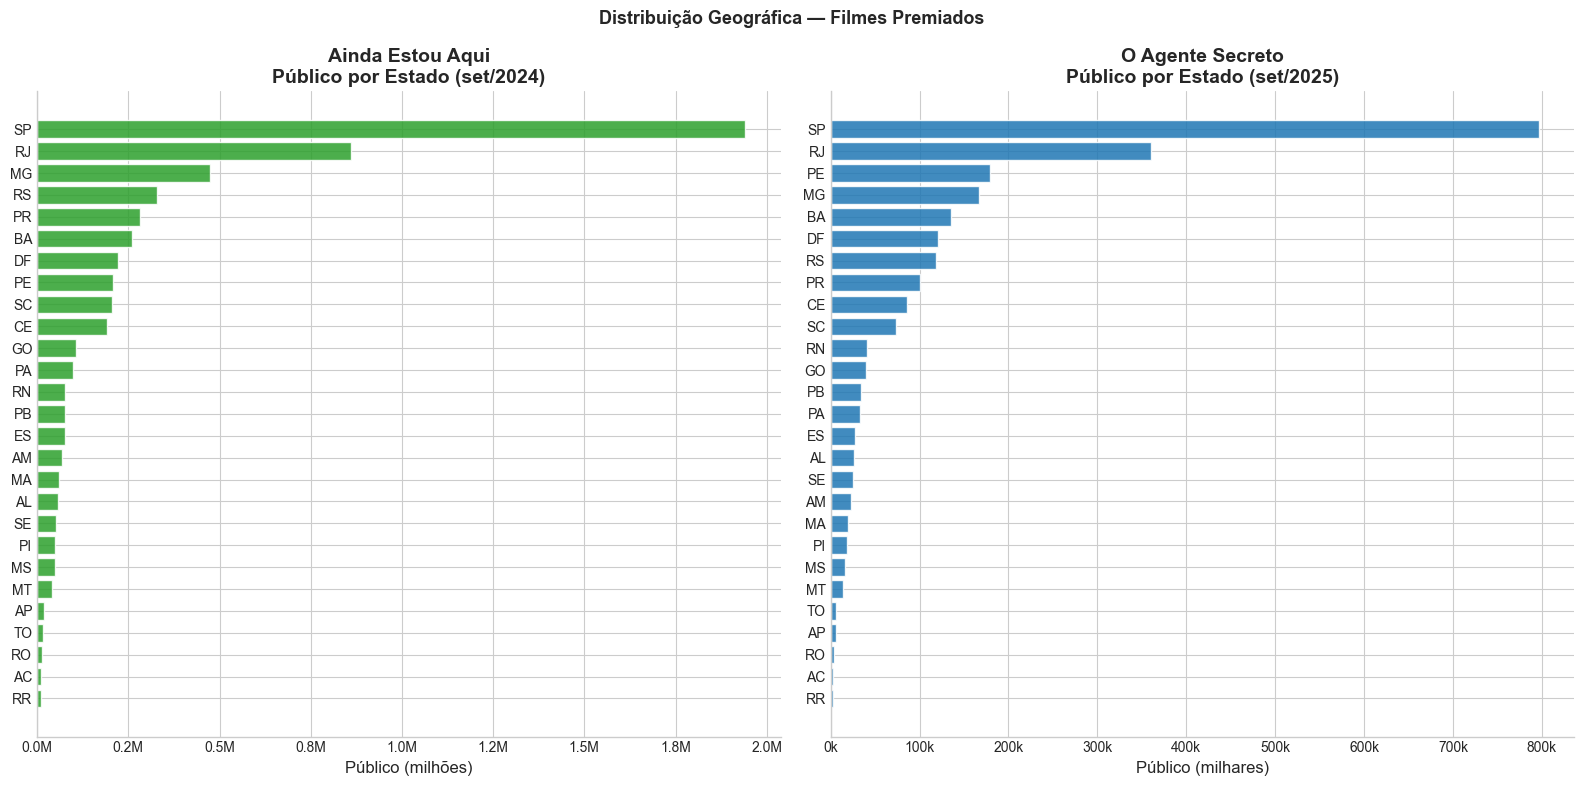

In [27]:
# ═══════════════════════════════════════════════════════════════
# 8.3 — DISTRIBUIÇÃO GEOGRÁFICA POR ESTADO
# ═══════════════════════════════════════════════════════════════
# Comparar como cada filme distribuiu seu público entre os estados.
# Filmes com distribuição mais uniforme indicam maior alcance nacional.

# Mês/ano de estreia (primeira exibição em cartaz), para os títulos dos gráficos
estreia_aea = aea['DATA_EXIBICAO'].min()
estreia_oas = oas['DATA_EXIBICAO'].min()

pub_uf_aea = (
    aea.groupby('UF_SALA_COMPLEXO', observed=True)['PUBLICO']
       .sum()
       .sort_values(ascending=True)  # ascendente para barh com maior no topo
)
pub_uf_oas = (
    oas.groupby('UF_SALA_COMPLEXO', observed=True)['PUBLICO']
       .sum()
       .sort_values(ascending=True)
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Ainda Estou Aqui por UF
ax1.barh(pub_uf_aea.index, pub_uf_aea.values,
         color=CORES['destaque'], alpha=0.85, edgecolor='white')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(formatar_milhoes))
ax1.set_title(f'Ainda Estou Aqui\nPúblico por Estado ({MESES_PT[estreia_aea.month].lower()}/{estreia_aea.year})', fontweight='bold')
ax1.set_xlabel('Público (milhões)')

# O Agente Secreto por UF
ax2.barh(pub_uf_oas.index, pub_uf_oas.values,
         color=CORES['nacional'], alpha=0.85, edgecolor='white')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax2.set_title(f'O Agente Secreto\nPúblico por Estado ({MESES_PT[estreia_oas.month].lower()}/{estreia_oas.year})', fontweight='bold')
ax2.set_xlabel('Público (milhares)')

plt.suptitle('Distribuição Geográfica — Filmes Premiados', fontsize=13, fontweight='bold')
plt.tight_layout()
salvar_figura('09_filmes_premiados_geografico.png')
plt.show()

> **Leitura do gráfico:** Compara como o público de cada filme premiado se distribuiu entre os estados, permitindo avaliar se o alcance geográfico foi mais concentrado ou mais uniforme.

In [28]:
# ═══════════════════════════════════════════════════════════════
# 8.4 — COMPARAÇÃO COM A MÉDIA DE FILMES NACIONAIS
# ═══════════════════════════════════════════════════════════════
# Para contextualizar o desempenho dos dois filmes premiados,
# comparamos com a mediana de público dos filmes nacionais
# lançados nos mesmos períodos (usando mediana para evitar
# que os próprios filmes analisados distorçam a referência).

# Período de cada filme nos dados
periodo_aea = (aea['DATA_EXIBICAO'].min(), aea['DATA_EXIBICAO'].max())
periodo_oas = (oas['DATA_EXIBICAO'].min(), oas['DATA_EXIBICAO'].max())

def pub_total_por_filme(df_filtrado, excluir_titulo=None):
    """Retorna o público total por filme, excluindo opcionalmente um título."""
    base = df_filtrado[df_filtrado['ORIGEM'] == 'Nacional'].copy()
    if excluir_titulo:
        base = base[base['TITULO_ORIGINAL'] != excluir_titulo]
    return base.groupby('TITULO_ORIGINAL', observed=True)['PUBLICO'].sum()

# Filmes nacionais no período de exibição de cada premiado (excluindo ele mesmo)
nacionais_aea_periodo = pub_total_por_filme(
    df[(df['DATA_EXIBICAO'] >= periodo_aea[0]) & (df['DATA_EXIBICAO'] <= periodo_aea[1])],
    excluir_titulo='AINDA ESTOU AQUI',
)
nacionais_oas_periodo = pub_total_por_filme(
    df[(df['DATA_EXIBICAO'] >= periodo_oas[0]) & (df['DATA_EXIBICAO'] <= periodo_oas[1])],
    excluir_titulo='O AGENTE SECRETO',
)

pub_aea = aea['PUBLICO'].sum()
pub_oas = oas['PUBLICO'].sum()
mediana_aea = nacionais_aea_periodo.median()
mediana_oas = nacionais_oas_periodo.median()

print('Comparação com a mediana de filmes nacionais no mesmo período:')
print()
print(f'  Ainda Estou Aqui:')
print(f'    Público total:                  {pub_aea:>10,.0f}')
print(f'    Mediana dos demais nacionais:   {mediana_aea:>10,.0f}')
print(f'    Múltiplo (quantas vezes maior): {pub_aea/mediana_aea:>10.0f}x')
print()
print(f'  O Agente Secreto:')
print(f'    Público total:                  {pub_oas:>10,.0f}')
print(f'    Mediana dos demais nacionais:   {mediana_oas:>10,.0f}')
print(f'    Múltiplo (quantas vezes maior): {pub_oas/mediana_oas:>10.0f}x')

# Salvar dados dos filmes premiados
aea_diario[['DATA_EXIBICAO', 'PUBLICO', 'PUBLICO_ACUM']].to_csv(
    OUTPUT_DATA_DIR / 'ainda_estou_aqui_diario.csv', index=False
)
oas_diario[['DATA_EXIBICAO', 'PUBLICO', 'PUBLICO_ACUM']].to_csv(
    OUTPUT_DATA_DIR / 'agente_secreto_diario.csv', index=False
)
print('\nDados diários salvos em outputs/processados/')

Comparação com a mediana de filmes nacionais no mesmo período:

  Ainda Estou Aqui:
    Público total:                   5,857,612
    Mediana dos demais nacionais:          580
    Múltiplo (quantas vezes maior):      10099x

  O Agente Secreto:
    Público total:                   2,476,469
    Mediana dos demais nacionais:          497
    Múltiplo (quantas vezes maior):       4983x

Dados diários salvos em outputs/processados/


---
## Seção 9 — Distribuição Geográfica

O mercado de cinema brasileiro é geograficamente concentrado. São Paulo e Rio de
Janeiro sozinhos historicamente respondem por mais da metade de todo o público
nacional — reflexo da distribuição de renda, infraestrutura de salas e densidade
populacional.

Esta seção analisa a distribuição do público por estado e por município,
e mede o grau de concentração geográfica do mercado.

Figura salva: outputs/figures/10_publico_por_uf.png


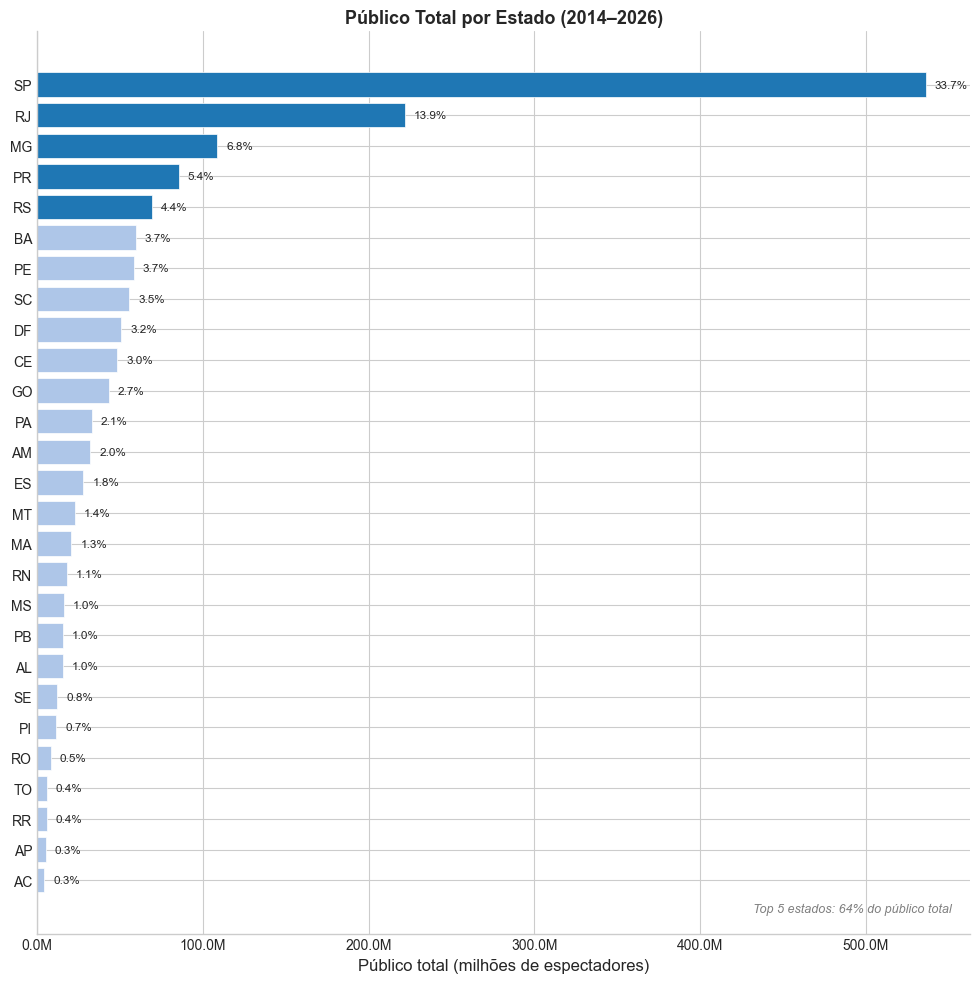

Dados salvos em outputs/processados/publico_por_uf.csv


In [29]:
# ═══════════════════════════════════════════════════════════════
# 9.1 — PÚBLICO POR ESTADO (UF)
# ═══════════════════════════════════════════════════════════════
# Usar todo o período e todos os anos (inclusive 2026 parcial,
# pois estamos comparando participação relativa, não total absoluto).

pub_por_uf = (
    df.groupby('UF_SALA_COMPLEXO', observed=True)['PUBLICO']
      .sum()
      .sort_values(ascending=True)  # ascendente para barh com maior no topo
      .reset_index()
)
pub_por_uf.columns = ['UF', 'PUBLICO']
pub_por_uf['PCT'] = pub_por_uf['PUBLICO'] / pub_por_uf['PUBLICO'].sum() * 100

fig, ax = plt.subplots(figsize=(10, 10))

# Colorir os top 5 estados de forma diferente para destacá-los
top5_ufs = pub_por_uf.nlargest(5, 'PUBLICO')['UF'].tolist()
cores_uf = [
    CORES['nacional'] if uf in top5_ufs else '#aec6e8'
    for uf in pub_por_uf['UF']
]

bars = ax.barh(
    pub_por_uf['UF'],
    pub_por_uf['PUBLICO'],
    color=cores_uf,
    edgecolor='white', linewidth=0.5,
)

# Rótulo com percentual em cada barra
for bar, pct in zip(bars, pub_por_uf['PCT']):
    ax.text(
        bar.get_width() + pub_por_uf['PUBLICO'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{pct:.1f}%',
        va='center', fontsize=8.5,
    )

ax.xaxis.set_major_formatter(mticker.FuncFormatter(formatar_milhoes))
ax.set_title('Público Total por Estado (2014–2026)', fontweight='bold', fontsize=13)
ax.set_xlabel('Público total (milhões de espectadores)')
ax.set_ylabel('')

# Nota sobre concentração
top5_pct = pub_por_uf.nlargest(5, 'PUBLICO')['PCT'].sum()
ax.text(
    0.98, 0.02,
    f'Top 5 estados: {top5_pct:.0f}% do público total',
    transform=ax.transAxes, ha='right', va='bottom',
    fontsize=9, style='italic', color='gray',
)

plt.tight_layout()
salvar_figura('10_publico_por_uf.png')
plt.show()

# Salvar
pub_por_uf.to_csv(OUTPUT_DATA_DIR / 'publico_por_uf.csv', index=False)
print('Dados salvos em outputs/processados/publico_por_uf.csv')

> **Leitura do gráfico:** Ranqueia todos os estados por público total acumulado no período, destacando os 5 estados de maior participação e o quanto eles concentram do público nacional.

Concentração por estado:
  Top 3 estados:  54.4% do público total
  Top 5 estados:  64.2% do público total
  Top 10 estados: 81.3% do público total



Figura salva: outputs/figures/11_top10_municipios.png


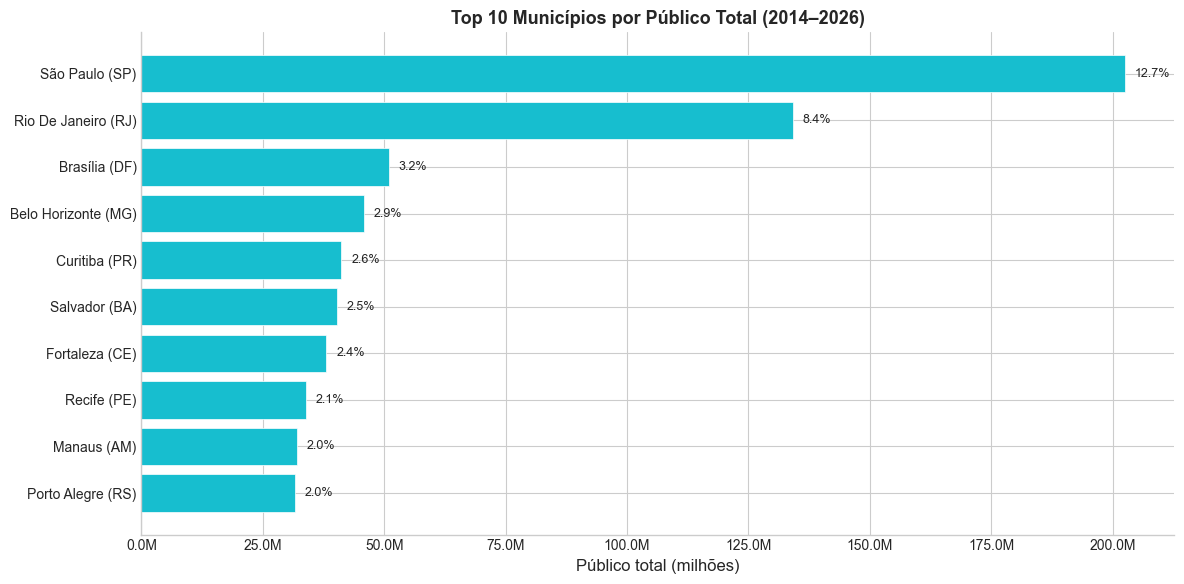

In [30]:
# ═══════════════════════════════════════════════════════════════
# 9.2 — CONCENTRAÇÃO GEOGRÁFICA E TOP MUNICÍPIOS
# ═══════════════════════════════════════════════════════════════

# Métricas de concentração por estado
total_geral = pub_por_uf['PUBLICO'].sum()
top3  = pub_por_uf.nlargest(3, 'PUBLICO')
top5  = pub_por_uf.nlargest(5, 'PUBLICO')
top10 = pub_por_uf.nlargest(10, 'PUBLICO')

print('Concentração por estado:')
print(f'  Top 3 estados:  {top3["PCT"].sum():.1f}% do público total')
print(f'  Top 5 estados:  {top5["PCT"].sum():.1f}% do público total')
print(f'  Top 10 estados: {top10["PCT"].sum():.1f}% do público total')
print()

# Top 10 municípios
pub_por_municipio = (
    df.groupby(['MUNICIPIO_SALA_COMPLEXO', 'UF_SALA_COMPLEXO'], observed=True)['PUBLICO']
      .sum()
      .reset_index()
      .sort_values('PUBLICO', ascending=False)
      .head(10)
)
pub_por_municipio['LABEL'] = (
    pub_por_municipio['MUNICIPIO_SALA_COMPLEXO'].astype(str).str.title() + ' (' +
    pub_por_municipio['UF_SALA_COMPLEXO'].astype(str) + ')'
)
pub_por_municipio['PCT'] = pub_por_municipio['PUBLICO'] / total_geral * 100

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    range(len(pub_por_municipio)),
    pub_por_municipio['PUBLICO'],
    color=CORES['total'], edgecolor='white', linewidth=0.5,
)
for bar, pct in zip(bars, pub_por_municipio['PCT']):
    ax.text(
        bar.get_width() + pub_por_municipio['PUBLICO'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{pct:.1f}%',
        va='center', fontsize=9,
    )

ax.set_yticks(range(len(pub_por_municipio)))
ax.set_yticklabels(pub_por_municipio['LABEL'], fontsize=10)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(formatar_milhoes))
ax.set_title('Top 10 Municípios por Público Total (2014–2026)', fontweight='bold', fontsize=13)
ax.set_xlabel('Público total (milhões)')

plt.tight_layout()
salvar_figura('11_top10_municipios.png')
plt.show()

> **Leitura do gráfico:** Detalha os 10 municípios de maior público total, complementando a visão por estado com o nível de concentração em grandes centros urbanos.

---
## Seção 10 — Sazonalidade

O consumo de cinema tem padrões sazonais bem estabelecidos: férias escolares
e feriados prolongados concentram os maiores públicos, enquanto início de ano
letivo e período de Quaresma tendem a ser mais fracos.

Para identificar a sazonalidade *estrutural* do mercado, excluímos os anos
atípicos da análise:
- **2020 e 2021:** pandemia — cinemas fechados ou com restrições graves
- **2026:** ano incompleto (apenas jan–jun)

A base de cálculo é a média do público por mês do ano, sobre os anos de 2014 a 2025
(exceto 2020 e 2021).

Figura salva: outputs/figures/12_sazonalidade.png


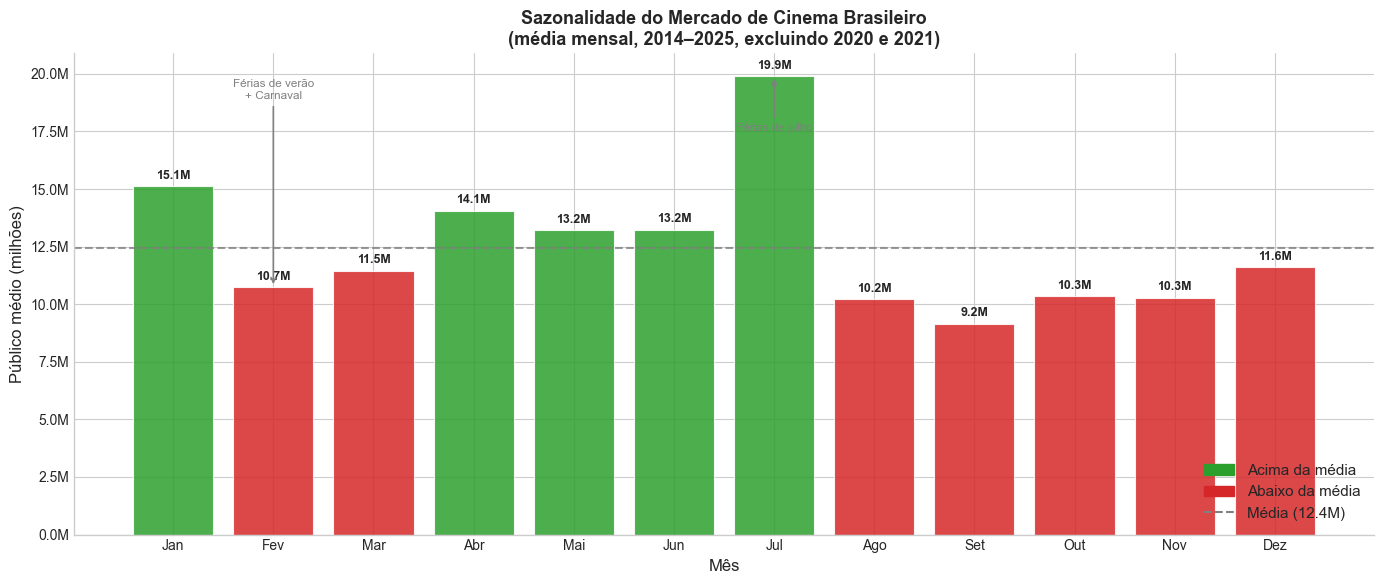

In [31]:
# ═══════════════════════════════════════════════════════════════
# 10.1 — PADRÃO DE SAZONALIDADE (MÉDIA POR MÊS DO ANO)
# ═══════════════════════════════════════════════════════════════
# Excluir anos atípicos para não distorcer a sazonalidade histórica
ANOS_EXCLUIR = [2020, 2021, 2026]

df_sazonal = df[~df['ANO'].isin(ANOS_EXCLUIR)].copy()

# Calcular o público total por mês em cada ano, depois tirar a média
# (média de totais mensais, não média de registros individuais)
pub_mes_ano = (
    df_sazonal
    .groupby(['ANO', 'MES'], observed=True)['PUBLICO']
    .sum()
    .reset_index()
)
sazonalidade = (
    pub_mes_ano
    .groupby('MES')['PUBLICO']
    .mean()
    .reset_index()
)

# MESES_PT (nomes dos meses em português) já definido na Seção 0 — Setup
sazonalidade['MES_NOME'] = sazonalidade['MES'].map(MESES_PT)

# Média geral (referência horizontal)
media_geral = sazonalidade['PUBLICO'].mean()

fig, ax = plt.subplots(figsize=(14, 6))

# Colorir meses acima/abaixo da média
cores_meses = [
    CORES['destaque'] if v >= media_geral else CORES['pandemia']
    for v in sazonalidade['PUBLICO']
]

bars = ax.bar(
    sazonalidade['MES_NOME'],
    sazonalidade['PUBLICO'],
    color=cores_meses,
    edgecolor='white', linewidth=0.8, alpha=0.85,
)

# Linha de média geral
ax.axhline(
    media_geral, color='gray', linestyle='--', linewidth=1.5, alpha=0.8,
    label=f'Média mensal ({media_geral/1_000_000:.1f}M)',
)

# Rótulo de valor sobre cada barra
for bar, val in zip(bars, sazonalidade['PUBLICO']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + media_geral * 0.015,
        f'{val/1_000_000:.1f}M',
        ha='center', va='bottom', fontsize=9, fontweight='bold',
    )

# Anotações dos picos sazonais conhecidos
ax.annotate(
    'Férias de verão\n+ Carnaval',
    xy=(1, sazonalidade.loc[sazonalidade['MES'] == 2, 'PUBLICO'].values[0]),
    xytext=(1, sazonalidade['PUBLICO'].max() * 0.95),
    arrowprops=dict(arrowstyle='->', color='gray', lw=1.2),
    fontsize=8.5, color='gray', ha='center',
)
ax.annotate(
    'Férias de julho',
    xy=(6, sazonalidade.loc[sazonalidade['MES'] == 7, 'PUBLICO'].values[0]),
    xytext=(6, sazonalidade['PUBLICO'].max() * 0.88),
    arrowprops=dict(arrowstyle='->', color='gray', lw=1.2),
    fontsize=8.5, color='gray', ha='center',
)

from matplotlib.patches import Patch
legenda = [
    Patch(color=CORES['destaque'],  label='Acima da média'),
    Patch(color=CORES['pandemia'],  label='Abaixo da média'),
]
ax.legend(handles=legenda + [plt.Line2D([0], [0], color='gray',
          linestyle='--', label=f'Média ({media_geral/1_000_000:.1f}M)')],
          loc='lower right')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatar_milhoes))
ax.set_title(
    'Sazonalidade do Mercado de Cinema Brasileiro\n'
    '(média mensal, 2014–2025, excluindo 2020 e 2021)',
    fontweight='bold', fontsize=13,
)
ax.set_xlabel('Mês')
ax.set_ylabel('Público médio (milhões)')

plt.tight_layout()
salvar_figura('12_sazonalidade.png')
plt.show()

> **Leitura do gráfico:** Mostra o padrão médio de público por mês do ano (excluindo os anos atípicos de pandemia e o 2026 incompleto), destacando os meses acima e abaixo da média geral e os picos ligados a férias escolares.

Figura salva: outputs/figures/13_sazonalidade_por_origem.png


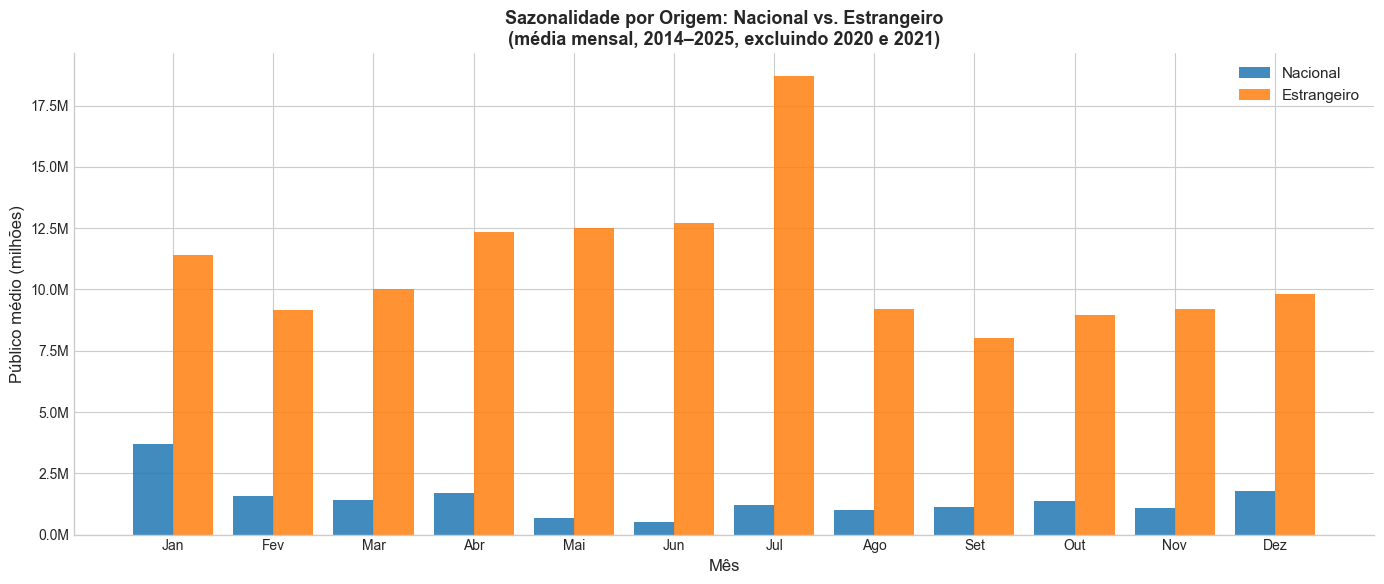

Análise concluída! Todos os outputs foram salvos em outputs/figures/ e outputs/processados/


In [32]:
# ═══════════════════════════════════════════════════════════════
# 10.2 — SAZONALIDADE POR ORIGEM: NACIONAL vs. ESTRANGEIRO
# ═══════════════════════════════════════════════════════════════
# A sazonalidade pode variar entre cinema nacional e estrangeiro:
# filmes de grandes estúdios americanos concentram lançamentos
# no verão e no final do ano, enquanto o cinema nacional pode
# ter um comportamento ligeiramente diferente.

pub_mes_origem = (
    df_sazonal
    .groupby(['ANO', 'MES', 'ORIGEM'], observed=True)['PUBLICO']
    .sum()
    .reset_index()
    .groupby(['MES', 'ORIGEM'], observed=True)['PUBLICO']
    .mean()
    .reset_index()
)

nac = pub_mes_origem[pub_mes_origem['ORIGEM'] == 'Nacional'].set_index('MES')['PUBLICO']
est = pub_mes_origem[pub_mes_origem['ORIGEM'] == 'Estrangeiro'].set_index('MES')['PUBLICO']

meses_nomes = [MESES_PT[m] for m in range(1, 13)]

fig, ax = plt.subplots(figsize=(14, 6))

x = range(12)
largura = 0.4
ax.bar([i - largura/2 for i in x], nac.values, width=largura,
       color=CORES['nacional'], label='Nacional', alpha=0.85)
ax.bar([i + largura/2 for i in x], est.values, width=largura,
       color=CORES['estrangeiro'], label='Estrangeiro', alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(meses_nomes)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatar_milhoes))
ax.set_title(
    'Sazonalidade por Origem: Nacional vs. Estrangeiro\n'
    '(média mensal, 2014–2025, excluindo 2020 e 2021)',
    fontweight='bold', fontsize=13,
)
ax.set_xlabel('Mês')
ax.set_ylabel('Público médio (milhões)')
ax.legend()

plt.tight_layout()
salvar_figura('13_sazonalidade_por_origem.png')
plt.show()

print('Análise concluída! Todos os outputs foram salvos em outputs/figures/ e outputs/processados/')

> **Leitura do gráfico:** Compara o padrão sazonal do cinema nacional com o do estrangeiro lado a lado, mês a mês, permitindo verificar se lançamentos nacionais e internacionais se concentram nas mesmas épocas do ano.